# Overlap Group-Rep Signature Similarity

This notebook starts from the overlap-filtered `.h5ad` files produced by `scripts/build_overlap_filtered_h5ads.py` to determine the retained lines and matched grouped-replicate samples, then loads the corresponding per-line DE files from the source result directories.

For each dataset pair, it reconstructs matches using the same rule as the overlap script / heatmap notebook:

- same `pubchem_cid`
- same `cell_type`
- same `pert_time_h`
- mutual nearest neighbors in `log10(pert_dose_uM)`
- `|Δ log10 dose| <= 1`
- a `cell_type + pert_time_h` context is included for a dataset pair only if that pair shares at least `10` matched drugs in that context

For every matched grouped-replicate sample pair, the notebook computes:

- signed Spearman correlation across genes on `logFC`
- signed Spearman correlation across genes on `t`
- signed overlap@50 on `t`, using the top 50 and bottom 50 genes

All signature metrics are computed twice:

- on the usual pairwise shared gene set for that dataset pair / line comparison
- on the line-specific multi-dataset gene set for that `cell_type`, defined as the genes shared across all active datasets that retain that line, exposed via `*_global` columns in the saved tables

It also computes a baseline for each matched sample: the average signature across other non-control compounds from the same dataset, line, dose, and time. Baseline metrics are evaluated on the same gene space as the corresponding observed metric, both for the pairwise shared-gene evaluation and for the line-specific multi-dataset shared-gene evaluation.

For summary tables, matched sample pairs are first averaged within each `pubchem_cid + cell_type + pert_time_h` case across all matched doses, then those drug-line-time cases are averaged to get the dataset-pair and dataset-pair-line summaries.

Outputs are written to `results/overlap_signature_similarity_group_rep/`.


In [1]:
import os

# Run only the Tahoe–sci-Plex comparison.
os.environ["CPB_DATASET_SUBSET"] = "tahoe,sciplex"

# Keep test outputs isolated from production results.
os.environ["CPB_RUN_TAG"] = "tahoe_sciplex_smoke"

# Use the production W4 population definition, not the reduced smoke population.
os.environ.pop("CPB_W4_SMOKE_COMPARISON_POPULATION", None)

# Wait for the shared W4 precompute if it is still running.
os.environ["CPB_W4_PRECOMPUTE_MODE"] = "wait"

# Reuse compatible cached outputs.
os.environ.pop("CPB_FORCE_RECOMPUTE", None)

print("Configured Tahoe + sci-Plex isolated test run.")

Configured Tahoe + sci-Plex isolated test run.


In [2]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import itertools
import os

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import rankdata


sns.set_theme(style="whitegrid")


In [3]:
# Set this to a list such as ["tahoe", "sciplex"] for an isolated test run.
# Leave it as None for the production dataset set and production output directory.
DATASET_SUBSET_ENV = os.environ.get("CPB_DATASET_SUBSET", "").strip()
TEST_DATASET_SUBSET = (
    None
    if not DATASET_SUBSET_ENV
    else [value.strip() for value in DATASET_SUBSET_ENV.split(",") if value.strip()]
)

def find_repo_root(start=None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import scripts.cross_source_core as cross_source_core

ANALYSIS_PROFILE = "signature"
PRODUCTION_DATASET_ORDER = cross_source_core.production_dataset_order(ANALYSIS_PROFILE)
DATASET_ORDER = cross_source_core.selected_dataset_order(ANALYSIS_PROFILE, TEST_DATASET_SUBSET)
DISPLAY_LABELS = dict(cross_source_core.DISPLAY_LABELS)
MATCH_SETTINGS = cross_source_core.DEFAULT_MATCH_SETTINGS
MAX_LOG10_DOSE_DIFF = MATCH_SETTINGS.max_log10_dose_diff
MIN_CONTEXT_SHARED_DRUGS = MATCH_SETTINGS.min_context_shared_drugs
TOP_K = cross_source_core.TOP_K
NUMERIC_SIG_FIGS = cross_source_core.NUMERIC_SIG_FIGS
INVALID_STRING_VALUES = cross_source_core.INVALID_STRING_VALUES
DATA_ROOT = REPO_ROOT / "data" / "theislab_temp"
SOURCE_DATASET_DIRS = cross_source_core.source_dataset_dirs(DATA_ROOT, ANALYSIS_PROFILE)
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
PRODUCTION_OUTPUT_DIR = REPO_ROOT / "results" / "overlap_signature_similarity_group_rep"
RUN_TAG = os.environ.get("CPB_RUN_TAG", "").strip()
OUTPUT_DIR = cross_source_core.analysis_output_dir(
    PRODUCTION_OUTPUT_DIR,
    dataset_subset=TEST_DATASET_SUBSET,
    dataset_names=DATASET_ORDER,
    run_tag=RUN_TAG,
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
print(f"Datasets selected: {', '.join(DATASET_ORDER)}")
print(f"Output directory: {OUTPUT_DIR}")

# --- Resumability -----------------------------------------------------------------
# Expensive stages below go through cached_frame: if the stage's output TSV already
# exists it is reloaded instead of recomputed, so this notebook can be restarted after
# a crash without redoing the work above the failure.
#
#   force_recompute("peer_baselines")   # rebuild one stage
#   CPB_FORCE_RECOMPUTE=all jupyter lab # ignore every cache
# Deleting a stage's TSV has the same effect as naming it.
# Stages here: matched_pairs, signature_metrics, signature_ci, peer_baselines, peer_ci,
# w4_signature_metrics, and w4_signature_ci.
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cross_source_strata import SignatureStratum
from scripts.notebook_cache import (
    ProgressReporter,
    cache_summary,
    cached_frame,
    force_recompute,
    frame_identity_fingerprint,
    is_cached,
    stable_json_fingerprint,
)

Repository root: /home/cirro/Chem-PerturBridge_analysis
Overlap directory: /home/cirro/Chem-PerturBridge_analysis/results/overlap_filtered_h5ads
Datasets selected: tahoe, sciplex
Output directory: /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke


In [4]:
# Shared cross-source utilities.
pretty_label = cross_source_core.pretty_label
format_numeric = cross_source_core.format_numeric


In [5]:
# One shared source catalog owns backed H5AD handles and gene-position caches.
SOURCE_CATALOG = cross_source_core.LineSourceCatalog(SOURCE_DATASET_DIRS)
LineSource = cross_source_core.LineSource
resolve_line_path = SOURCE_CATALOG.resolve_line_path
get_line_source = SOURCE_CATALOG.get_line_source
shared_gene_positions = SOURCE_CATALOG.shared_gene_positions
set_global_shared_gene_keys = SOURCE_CATALOG.set_global_shared_gene_keys
global_gene_positions = SOURCE_CATALOG.global_gene_positions
close_all_line_sources = SOURCE_CATALOG.close

# Compatibility aliases used by the metric-specific cells below.
filter_finite_pair = cross_source_core.filter_finite_pair
signed_spearman = cross_source_core.signed_spearman
signed_overlap_at_k = cross_source_core.signed_overlap_at_k
score_signature_pair = cross_source_core.score_signature_pair
mean_available = cross_source_core.mean_available
empty_score_dict = cross_source_core.empty_score_dict


# Table 6 signature-specific record construction.
def compute_metric_record(match_row: pd.Series) -> dict[str, object]:
    left_source = get_line_source(str(match_row["dataset_a"]), str(match_row["cell_type"]))
    right_source = get_line_source(str(match_row["dataset_b"]), str(match_row["cell_type"]))
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {match_row['dataset_a']} vs {match_row['dataset_b']} / {match_row['cell_type']}"
        )

    global_shared_genes, left_global_gene_pos = global_gene_positions(left_source)
    _, right_global_gene_pos = global_gene_positions(right_source)

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])

    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc_full = left_source.get_vector(left_obs_id, "logFC", **left_lookup)
    right_logfc_full = right_source.get_vector(right_obs_id, "logFC", **right_lookup)
    left_t_full = left_source.get_vector(left_obs_id, "t", **left_lookup)
    right_t_full = right_source.get_vector(right_obs_id, "t", **right_lookup)

    observed_scores = score_signature_pair(
        left_logfc=left_logfc_full[left_gene_pos],
        right_logfc=right_logfc_full[right_gene_pos],
        left_t=left_t_full[left_gene_pos],
        right_t=right_t_full[right_gene_pos],
    )

    observed_scores_global = empty_score_dict()
    if global_shared_genes.size >= 2:
        observed_scores_global = score_signature_pair(
            left_logfc=left_logfc_full[left_global_gene_pos],
            right_logfc=right_logfc_full[right_global_gene_pos],
            left_t=left_t_full[left_global_gene_pos],
            right_t=right_t_full[right_global_gene_pos],
        )

    left_mean_abs_t = mean_available(np.abs(left_t_full[left_gene_pos]).tolist())
    right_mean_abs_t = mean_available(np.abs(right_t_full[right_gene_pos]).tolist())
    pair_mean_abs_t = mean_available([left_mean_abs_t, right_mean_abs_t])

    left_mean_abs_t_global = float("nan")
    right_mean_abs_t_global = float("nan")
    pair_mean_abs_t_global = float("nan")
    if global_shared_genes.size >= 2:
        left_mean_abs_t_global = mean_available(np.abs(left_t_full[left_global_gene_pos]).tolist())
        right_mean_abs_t_global = mean_available(np.abs(right_t_full[right_global_gene_pos]).tolist())
        pair_mean_abs_t_global = mean_available([left_mean_abs_t_global, right_mean_abs_t_global])

    left_baseline_logfc_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    left_baseline_t_full = left_source.get_baseline_vector(left_obs_id, "t", **left_lookup)
    right_baseline_logfc_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    right_baseline_t_full = right_source.get_baseline_vector(right_obs_id, "t", **right_lookup)

    left_baseline_scores = empty_score_dict()
    left_baseline_scores_global = empty_score_dict()
    if left_baseline_logfc_full is not None and left_baseline_t_full is not None:
        left_baseline_scores = score_signature_pair(
            left_logfc=left_logfc_full[left_gene_pos],
            right_logfc=left_baseline_logfc_full[left_gene_pos],
            left_t=left_t_full[left_gene_pos],
            right_t=left_baseline_t_full[left_gene_pos],
        )
        if global_shared_genes.size >= 2:
            left_baseline_scores_global = score_signature_pair(
                left_logfc=left_logfc_full[left_global_gene_pos],
                right_logfc=left_baseline_logfc_full[left_global_gene_pos],
                left_t=left_t_full[left_global_gene_pos],
                right_t=left_baseline_t_full[left_global_gene_pos],
            )

    right_baseline_scores = empty_score_dict()
    right_baseline_scores_global = empty_score_dict()
    if right_baseline_logfc_full is not None and right_baseline_t_full is not None:
        right_baseline_scores = score_signature_pair(
            left_logfc=right_logfc_full[right_gene_pos],
            right_logfc=right_baseline_logfc_full[right_gene_pos],
            left_t=right_t_full[right_gene_pos],
            right_t=right_baseline_t_full[right_gene_pos],
        )
        if global_shared_genes.size >= 2:
            right_baseline_scores_global = score_signature_pair(
                left_logfc=right_logfc_full[right_global_gene_pos],
                right_logfc=right_baseline_logfc_full[right_global_gene_pos],
                left_t=right_t_full[right_global_gene_pos],
                right_t=right_baseline_t_full[right_global_gene_pos],
            )

    overlap_column = f"signed_overlap_t_top{TOP_K}"
    return {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "n_global_common_genes": int(global_shared_genes.size),
        "left_mean_abs_t": left_mean_abs_t,
        "right_mean_abs_t": right_mean_abs_t,
        "pair_mean_abs_t": pair_mean_abs_t,
        "left_mean_abs_t_global": left_mean_abs_t_global,
        "right_mean_abs_t_global": right_mean_abs_t_global,
        "pair_mean_abs_t_global": pair_mean_abs_t_global,
        "observed_spearman_logfc": observed_scores["spearman_logfc"],
        "observed_spearman_logfc_global": observed_scores_global["spearman_logfc"],
        "observed_spearman_t": observed_scores["spearman_t"],
        "observed_spearman_t_global": observed_scores_global["spearman_t"],
        f"observed_{overlap_column}": observed_scores[overlap_column],
        f"observed_{overlap_column}_global": observed_scores_global[overlap_column],
        "left_baseline_peer_count": left_source.baseline_peer_count(left_obs_id, **left_lookup),
        "left_baseline_spearman_logfc": left_baseline_scores["spearman_logfc"],
        "left_baseline_spearman_logfc_global": left_baseline_scores_global["spearman_logfc"],
        "left_baseline_spearman_t": left_baseline_scores["spearman_t"],
        "left_baseline_spearman_t_global": left_baseline_scores_global["spearman_t"],
        f"left_baseline_{overlap_column}": left_baseline_scores[overlap_column],
        f"left_baseline_{overlap_column}_global": left_baseline_scores_global[overlap_column],
        "right_baseline_peer_count": right_source.baseline_peer_count(right_obs_id, **right_lookup),
        "right_baseline_spearman_logfc": right_baseline_scores["spearman_logfc"],
        "right_baseline_spearman_logfc_global": right_baseline_scores_global["spearman_logfc"],
        "right_baseline_spearman_t": right_baseline_scores["spearman_t"],
        "right_baseline_spearman_t_global": right_baseline_scores_global["spearman_t"],
        f"right_baseline_{overlap_column}": right_baseline_scores[overlap_column],
        f"right_baseline_{overlap_column}_global": right_baseline_scores_global[overlap_column],
        "baseline_pair_mean_spearman_logfc": mean_available(
            [left_baseline_scores["spearman_logfc"], right_baseline_scores["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_logfc_global": mean_available(
            [left_baseline_scores_global["spearman_logfc"], right_baseline_scores_global["spearman_logfc"]]
        ),
        "baseline_pair_mean_spearman_t": mean_available(
            [left_baseline_scores["spearman_t"], right_baseline_scores["spearman_t"]]
        ),
        "baseline_pair_mean_spearman_t_global": mean_available(
            [left_baseline_scores_global["spearman_t"], right_baseline_scores_global["spearman_t"]]
        ),
        f"baseline_pair_mean_{overlap_column}": mean_available(
            [left_baseline_scores[overlap_column], right_baseline_scores[overlap_column]]
        ),
        f"baseline_pair_mean_{overlap_column}_global": mean_available(
            [left_baseline_scores_global[overlap_column], right_baseline_scores_global[overlap_column]]
        ),
    }


In [6]:
cross_source_scope = cross_source_core.prepare_cross_source_scope(
    dataset_order=DATASET_ORDER,
    overlap_dir=OVERLAP_DIR,
    output_dir=OUTPUT_DIR,
    source_catalog=SOURCE_CATALOG,
    settings=MATCH_SETTINGS,
)
dataset_indices = cross_source_scope.dataset_indices
active_datasets = cross_source_scope.active_datasets
retained_lines = cross_source_scope.retained_lines
matched_pairs = cross_source_scope.matched_pairs
MATCHED_PAIRS_FINGERPRINT = cross_source_scope.matched_pairs_fingerprint
matched_lines = cross_source_scope.matched_lines
matched_active_datasets = cross_source_scope.matched_active_datasets
global_gene_lines = cross_source_scope.global_gene_lines
line_global_gene_keys = cross_source_scope.line_global_gene_keys
pair_match_summary = cross_source_scope.pair_match_summary
line_match_summary = cross_source_scope.line_match_summary

print("Datasets in scope:", ", ".join(
    pretty_label(dataset_name) for dataset_name in active_datasets
))
retained_lines_display = pd.DataFrame(
    {
        "dataset": [pretty_label(name) for name in retained_lines],
        "cell_types": [", ".join(lines) for lines in retained_lines.values()],
    }
)
display(retained_lines_display)

line_global_gene_counts = {
    cell_type: int(gene_keys.size)
    for cell_type, gene_keys in line_global_gene_keys.items()
}
n_opened_gene_sources = sum(len(lines) for lines in global_gene_lines.values())
n_available_gene_sources = sum(len(lines) for lines in retained_lines.values())
print(
    f"Line-specific shared-gene sets computed for {len(line_global_gene_counts):,} "
    f"matched cell types using {n_opened_gene_sources:,}/{n_available_gene_sources:,} "
    "available line sources."
)
if not line_global_gene_counts or max(line_global_gene_counts.values()) < 2:
    print(
        "Line-specific shared-gene evaluation will be unavailable because no "
        "matched line has at least two genes shared across the datasets that retain it."
    )
else:
    print(
        "Line-specific shared-gene count range across matched lines: "
        f"{min(line_global_gene_counts.values()):,} to "
        f"{max(line_global_gene_counts.values()):,}"
    )

pair_match_summary_display = pair_match_summary.copy()
pair_match_summary_display["dataset_a"] = pair_match_summary_display["dataset_a"].map(pretty_label)
pair_match_summary_display["dataset_b"] = pair_match_summary_display["dataset_b"].map(pretty_label)
display(pair_match_summary_display)

line_match_summary_display = line_match_summary.copy()
line_match_summary_display["dataset_a"] = line_match_summary_display["dataset_a"].map(pretty_label)
line_match_summary_display["dataset_b"] = line_match_summary_display["dataset_b"].map(pretty_label)
display(line_match_summary_display)


[matched_pairs] computed and saved 170 rows to matched_sample_pairs.tsv
Datasets in scope: Tahoe-100M, sci-Plex


,dataset,cell_types
0,Tahoe-100M,"CVCL_0023, CVCL_0320, CVCL_0332"
1,sci-Plex,"CVCL_0023, CVCL_0031"


Line-specific shared-gene sets computed for 1 matched cell types using 2/5 available line sources.
Line-specific shared-gene count range across matched lines: 6,742 to 6,742


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_drugs,n_matching_lines,n_matching_conditions
0,Tahoe-100M,sci-Plex,170,23,1,69


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions
0,Tahoe-100M,sci-Plex,CVCL_0023,170,23,69


In [7]:
metric_records: list[dict[str, object]] = []
unresolved_records: list[dict[str, object]] = []
context_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "left_dose_key",
    "right_dose_key",
]
matched_pair_metrics_path = OUTPUT_DIR / "matched_sample_pair_metrics.tsv"
SIGNATURE_METRICS_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "signature-metrics-v4-shared-core",
        "datasets": DATASET_ORDER,
        "matched_pairs": frame_identity_fingerprint(
            matched_pairs,
            cross_source_core.MATCH_PAIR_IDENTITY_COLUMNS,
        ),
        "top_k": TOP_K,
        "sources": cross_source_core.line_source_inventory(
            global_gene_lines,
            resolve_line_path,
        ),
    }
)
signature_metrics_is_cached = is_cached(
    "signature_metrics",
    matched_pair_metrics_path,
    fingerprint=SIGNATURE_METRICS_FINGERPRINT,
)
signature_progress = ProgressReporter(
    total=len(matched_pairs),
    label="signature_metrics",
    every=100,
    min_interval_seconds=20.0,
)
signature_metric_input = matched_pairs.iloc[0:0] if signature_metrics_is_cached else matched_pairs
for (dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key), group in signature_metric_input.groupby(
    context_join_columns,
    sort=False,
):
    print(
        f"Scoring {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / time={time_key} / doses={left_dose_key} vs {right_dose_key}: "
        f"{len(group)} matched sample pairs across {group['pubchem_cid'].nunique()} shared compounds"
    )
    for _, match_row in group.iterrows():
        try:
            metric_records.append(compute_metric_record(match_row))
        except KeyError as exc:
            unresolved_records.append(
                {
                    **match_row.to_dict(),
                    "error": str(exc),
                }
            )
        finally:
            signature_progress.update(
                detail=f"{pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type}"
            )

def build_signature_metrics() -> pd.DataFrame:
    matched_pair_metrics = pd.DataFrame(metric_records)
    return matched_pair_metrics


matched_pair_metrics = cached_frame(
    "signature_metrics",
    matched_pair_metrics_path,
    build_signature_metrics,
    fingerprint=SIGNATURE_METRICS_FINGERPRINT,
)
if matched_pair_metrics.empty:
    raise ValueError("No matched sample pairs could be resolved in the source line files.")

print(f"Scored {len(matched_pair_metrics):,} matched sample pairs")

unresolved_matches = pd.DataFrame(unresolved_records)
if unresolved_matches.empty:
    print("All matched sample pairs were resolved in the source line files.")
else:
    unresolved_matches_path = OUTPUT_DIR / "unresolved_matched_sample_pairs.tsv"
    unresolved_matches.to_csv(unresolved_matches_path, sep="	", index=False)
    print(
        f"Skipped {len(unresolved_matches):,} matched sample pairs with no corresponding grouped result in the source line files. "
        f"Saved details to {unresolved_matches_path}"
    )
    display(
        unresolved_matches.groupby(context_join_columns, as_index=False)
        .agg(n_unresolved=("error", "size"))
        .sort_values(context_join_columns)
        .reset_index(drop=True)
    )

matched_pair_metrics.head()

Scoring Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=0.05 vs 0.1: 52 matched sample pairs across 23 shared compounds
Scoring Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=0.5 vs 1: 52 matched sample pairs across 23 shared compounds
[signature_metrics] 100/170 (58.8%) | elapsed 00:06 | 15.60/s | ETA 00:04 | Tahoe-100M vs sci-Plex / CVCL_0023
Scoring Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=5 vs 10: 66 matched sample pairs across 23 shared compounds
[signature_metrics] 170/170 (100.0%) | elapsed 00:10 | 16.22/s | ETA 00:00 | Tahoe-100M vs sci-Plex / CVCL_0023
[signature_metrics] computed and saved 170 rows to matched_sample_pair_metrics.tsv
Scored 170 matched sample pairs
All matched sample pairs were resolved in the source line files.


,dataset_a,dataset_b,cell_type,pubchem_cid,time_key,left_obs_id,right_obs_id,left_plate,right_plate,left_well,...,right_baseline_spearman_t,right_baseline_spearman_t_global,right_baseline_signed_overlap_t_top50,right_baseline_signed_overlap_t_top50_global,baseline_pair_mean_spearman_logfc,baseline_pair_mean_spearman_logfc_global,baseline_pair_mean_spearman_t,baseline_pair_mean_spearman_t_global,baseline_pair_mean_signed_overlap_t_top50,baseline_pair_mean_signed_overlap_t_top50_global
0,tahoe,sciplex,CVCL_0023,104741,24,plate10_F3_fulvestrant_CVCL_0023,plate16_plate10_B6_fulvestrant_CVCL_0023,plate10,plate16,F3,...,0.168616,0.168616,0.04,0.04,0.343322,0.343322,0.351094,0.351094,0.085,0.085
1,tahoe,sciplex,CVCL_0023,104741,24,plate10_F3_fulvestrant_CVCL_0023,plate39_plate9_B12_fulvestrant_CVCL_0023,plate10,plate39,F3,...,0.168616,0.168616,0.04,0.04,0.343322,0.343322,0.351094,0.351094,0.085,0.085
2,tahoe,sciplex,CVCL_0023,11167602,24,plate1_B7_regorafenib_CVCL_0023,plate16_plate10_D3_regorafenib_CVCL_0023,plate1,plate16,B7,...,0.163093,0.163093,0.07,0.07,0.335142,0.335142,0.365894,0.365894,0.155,0.155
3,tahoe,sciplex,CVCL_0023,11167602,24,plate1_B7_regorafenib_CVCL_0023,plate39_plate9_D9_regorafenib_CVCL_0023,plate1,plate39,B7,...,0.163093,0.163093,0.07,0.07,0.335142,0.335142,0.365894,0.365894,0.155,0.155
4,tahoe,sciplex,CVCL_0023,11167602,24,plate13_H3_regorafenib_CVCL_0023,plate16_plate10_D3_regorafenib_CVCL_0023,plate13,plate16,H3,...,0.163093,0.163093,0.07,0.07,0.335142,0.335142,0.365894,0.365894,0.155,0.155


In [8]:
overlap_metric_column = f"observed_signed_overlap_t_top{TOP_K}"
baseline_overlap_column = f"baseline_pair_mean_signed_overlap_t_top{TOP_K}"
left_baseline_overlap_column = f"left_baseline_signed_overlap_t_top{TOP_K}"
right_baseline_overlap_column = f"right_baseline_signed_overlap_t_top{TOP_K}"
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]

metric_mean_columns = {
    "mean_common_genes": "n_common_genes",
    "mean_global_common_genes": "n_global_common_genes",
    "mean_left_mean_abs_t": "left_mean_abs_t",
    "mean_right_mean_abs_t": "right_mean_abs_t",
    "mean_pair_mean_abs_t": "pair_mean_abs_t",
    "mean_left_mean_abs_t_global": "left_mean_abs_t_global",
    "mean_right_mean_abs_t_global": "right_mean_abs_t_global",
    "mean_pair_mean_abs_t_global": "pair_mean_abs_t_global",
    "mean_observed_spearman_logfc": "observed_spearman_logfc",
    "mean_observed_spearman_logfc_global": "observed_spearman_logfc_global",
    "mean_observed_spearman_t": "observed_spearman_t",
    "mean_observed_spearman_t_global": "observed_spearman_t_global",
    f"mean_observed_signed_overlap_t_top{TOP_K}": overlap_metric_column,
    f"mean_observed_signed_overlap_t_top{TOP_K}_global": f"{overlap_metric_column}_global",
    "mean_baseline_pair_spearman_logfc": "baseline_pair_mean_spearman_logfc",
    "mean_baseline_pair_spearman_logfc_global": "baseline_pair_mean_spearman_logfc_global",
    "mean_baseline_pair_spearman_t": "baseline_pair_mean_spearman_t",
    "mean_baseline_pair_spearman_t_global": "baseline_pair_mean_spearman_t_global",
    f"mean_baseline_pair_signed_overlap_t_top{TOP_K}": baseline_overlap_column,
    f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global": f"{baseline_overlap_column}_global",
    "mean_left_baseline_spearman_logfc": "left_baseline_spearman_logfc",
    "mean_left_baseline_spearman_logfc_global": "left_baseline_spearman_logfc_global",
    "mean_left_baseline_spearman_t": "left_baseline_spearman_t",
    "mean_left_baseline_spearman_t_global": "left_baseline_spearman_t_global",
    f"mean_left_baseline_signed_overlap_t_top{TOP_K}": left_baseline_overlap_column,
    f"mean_left_baseline_signed_overlap_t_top{TOP_K}_global": f"{left_baseline_overlap_column}_global",
    "mean_right_baseline_spearman_logfc": "right_baseline_spearman_logfc",
    "mean_right_baseline_spearman_logfc_global": "right_baseline_spearman_logfc_global",
    "mean_right_baseline_spearman_t": "right_baseline_spearman_t",
    "mean_right_baseline_spearman_t_global": "right_baseline_spearman_t_global",
    f"mean_right_baseline_signed_overlap_t_top{TOP_K}": right_baseline_overlap_column,
    f"mean_right_baseline_signed_overlap_t_top{TOP_K}_global": f"{right_baseline_overlap_column}_global",
    "mean_left_baseline_peer_count": "left_baseline_peer_count",
    "mean_right_baseline_peer_count": "right_baseline_peer_count",
}

drug_line_time_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in metric_mean_columns.items():
    drug_line_time_agg[target_column] = (source_column, "mean")
drug_line_time_agg["n_pair_baselines_available"] = (
    "baseline_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
drug_line_time_agg["n_pair_baselines_available_global"] = (
    "baseline_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

drug_line_time_metric_summary = (
    matched_pair_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_summary_path = OUTPUT_DIR / "matched_drug_line_time_metric_summary.tsv"
drug_line_time_metric_summary.to_csv(drug_line_time_metric_summary_path, sep="	", index=False)
print(f"Saved drug-line-time metric summary to {drug_line_time_metric_summary_path}")

summary_mean_columns = [
    column_name for column_name in drug_line_time_metric_summary.columns if column_name.startswith("mean_")
]

pair_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    pair_agg[column_name] = (column_name, "mean")
pair_agg["n_pair_baselines_available"] = (
    "mean_baseline_pair_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
pair_agg["n_pair_baselines_available_global"] = (
    "mean_baseline_pair_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

pair_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_columns:
    line_agg[column_name] = (column_name, "mean")
line_agg["n_pair_baselines_available"] = (
    "mean_baseline_pair_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
line_agg["n_pair_baselines_available_global"] = (
    "mean_baseline_pair_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

line_metric_summary = (
    drug_line_time_metric_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_summary_path = OUTPUT_DIR / "dataset_pair_metric_summary.tsv"
line_metric_summary_path = OUTPUT_DIR / "dataset_pair_line_metric_summary.tsv"
pair_metric_summary.to_csv(pair_metric_summary_path, sep="	", index=False)
line_metric_summary.to_csv(line_metric_summary_path, sep="	", index=False)
print(f"Saved dataset-pair summary to {pair_metric_summary_path}")
print(f"Saved dataset-pair-line summary to {line_metric_summary_path}")

pair_metric_summary_display = pair_metric_summary.copy()
pair_metric_summary_display["dataset_a"] = pair_metric_summary_display["dataset_a"].map(pretty_label)
pair_metric_summary_display["dataset_b"] = pair_metric_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_summary_display)

line_metric_summary_display = line_metric_summary.copy()
line_metric_summary_display["dataset_a"] = line_metric_summary_display["dataset_a"].map(pretty_label)
line_metric_summary_display["dataset_b"] = line_metric_summary_display["dataset_b"].map(pretty_label)
display(line_metric_summary_display)


Saved drug-line-time metric summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/matched_drug_line_time_metric_summary.tsv
Saved dataset-pair summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_metric_summary.tsv
Saved dataset-pair-line summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_line_metric_summary.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_common_genes,mean_global_common_genes,mean_left_mean_abs_t,...,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,mean_left_baseline_peer_count,mean_right_baseline_peer_count,n_pair_baselines_available,n_pair_baselines_available_global
0,Tahoe-100M,sci-Plex,170,1,23,69,23,6742.0,6742.0,1.301665,...,0.220218,0.220218,0.21953,0.21953,0.047065,0.047065,376.416667,180.463768,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_common_genes,mean_global_common_genes,mean_left_mean_abs_t,...,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,mean_left_baseline_peer_count,mean_right_baseline_peer_count,n_pair_baselines_available,n_pair_baselines_available_global
0,Tahoe-100M,sci-Plex,CVCL_0023,170,23,69,23,6742.0,6742.0,1.301665,...,0.220218,0.220218,0.21953,0.21953,0.047065,0.047065,376.416667,180.463768,23,23


In [9]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_logfc"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_logfc_global"))


dataset_b,sciplex
dataset_a,
tahoe,0.052575


dataset_b,sciplex
dataset_a,
tahoe,0.052575


In [10]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_t"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_observed_spearman_t_global"))


dataset_b,sciplex
dataset_a,
tahoe,0.053621


dataset_b,sciplex
dataset_a,
tahoe,0.053621


In [11]:
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_signed_overlap_t_top{TOP_K}"))
display(pair_metric_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_observed_signed_overlap_t_top{TOP_K}_global"))


dataset_b,sciplex
dataset_a,
tahoe,0.025254


dataset_b,sciplex
dataset_a,
tahoe,0.025254


Baseline-adjusted final scores:

For each matched sample pair, these scores subtract the within-dataset same-line / same-time / same-dose other-compound baseline from the observed cross-dataset score. The subtraction is done separately for dataset A and dataset B on the same shared-gene subset used for the observed cross-dataset score, then averaged across the two sides.


In [12]:
drug_line_time_group_columns = ["dataset_a", "dataset_b", "cell_type", "time_key", "pubchem_cid"]
baseline_adjusted_metrics = matched_pair_metrics.copy()

metric_names = [
    "spearman_logfc",
    "spearman_t",
    f"signed_overlap_t_top{TOP_K}",
    "spearman_logfc_global",
    "spearman_t_global",
    f"signed_overlap_t_top{TOP_K}_global",
]

for metric_name in metric_names:
    observed_col = f"observed_{metric_name}"
    left_baseline_col = f"left_baseline_{metric_name}"
    right_baseline_col = f"right_baseline_{metric_name}"

    left_delta_col = f"delta_vs_left_baseline_{metric_name}"
    right_delta_col = f"delta_vs_right_baseline_{metric_name}"
    pair_mean_delta_col = f"delta_pair_mean_{metric_name}"

    baseline_adjusted_metrics[left_delta_col] = (
        baseline_adjusted_metrics[observed_col] - baseline_adjusted_metrics[left_baseline_col]
    )
    baseline_adjusted_metrics[right_delta_col] = (
        baseline_adjusted_metrics[observed_col] - baseline_adjusted_metrics[right_baseline_col]
    )
    baseline_adjusted_metrics[pair_mean_delta_col] = baseline_adjusted_metrics[
        [left_delta_col, right_delta_col]
    ].mean(axis=1)

baseline_adjusted_metrics_path = OUTPUT_DIR / "matched_sample_pair_metrics_baseline_adjusted.tsv"
baseline_adjusted_metrics.to_csv(baseline_adjusted_metrics_path, sep="	", index=False)
print(f"Saved baseline-adjusted matched-pair metrics to {baseline_adjusted_metrics_path}")

mean_delta_columns = {
    "mean_delta_pair_mean_spearman_logfc": "delta_pair_mean_spearman_logfc",
    "mean_delta_pair_mean_spearman_t": "delta_pair_mean_spearman_t",
    f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}": f"delta_pair_mean_signed_overlap_t_top{TOP_K}",
    "mean_delta_pair_mean_spearman_logfc_global": "delta_pair_mean_spearman_logfc_global",
    "mean_delta_pair_mean_spearman_t_global": "delta_pair_mean_spearman_t_global",
    f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}_global": f"delta_pair_mean_signed_overlap_t_top{TOP_K}_global",
    "mean_delta_vs_left_baseline_spearman_logfc": "delta_vs_left_baseline_spearman_logfc",
    "mean_delta_vs_left_baseline_spearman_t": "delta_vs_left_baseline_spearman_t",
    f"mean_delta_vs_left_baseline_signed_overlap_t_top{TOP_K}": f"delta_vs_left_baseline_signed_overlap_t_top{TOP_K}",
    "mean_delta_vs_left_baseline_spearman_logfc_global": "delta_vs_left_baseline_spearman_logfc_global",
    "mean_delta_vs_left_baseline_spearman_t_global": "delta_vs_left_baseline_spearman_t_global",
    f"mean_delta_vs_left_baseline_signed_overlap_t_top{TOP_K}_global": f"delta_vs_left_baseline_signed_overlap_t_top{TOP_K}_global",
    "mean_delta_vs_right_baseline_spearman_logfc": "delta_vs_right_baseline_spearman_logfc",
    "mean_delta_vs_right_baseline_spearman_t": "delta_vs_right_baseline_spearman_t",
    f"mean_delta_vs_right_baseline_signed_overlap_t_top{TOP_K}": f"delta_vs_right_baseline_signed_overlap_t_top{TOP_K}",
    "mean_delta_vs_right_baseline_spearman_logfc_global": "delta_vs_right_baseline_spearman_logfc_global",
    "mean_delta_vs_right_baseline_spearman_t_global": "delta_vs_right_baseline_spearman_t_global",
    f"mean_delta_vs_right_baseline_signed_overlap_t_top{TOP_K}_global": f"delta_vs_right_baseline_signed_overlap_t_top{TOP_K}_global",
}

drug_line_time_delta_agg = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for target_column, source_column in mean_delta_columns.items():
    drug_line_time_delta_agg[target_column] = (source_column, "mean")
drug_line_time_delta_agg["n_pair_mean_deltas_available"] = (
    "delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
drug_line_time_delta_agg["n_pair_mean_deltas_available_global"] = (
    "delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

drug_line_time_metric_baseline_adjusted_summary = (
    baseline_adjusted_metrics.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**drug_line_time_delta_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
drug_line_time_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "matched_drug_line_time_metric_baseline_adjusted_summary.tsv"
drug_line_time_metric_baseline_adjusted_summary.to_csv(drug_line_time_metric_baseline_adjusted_summary_path, sep="	", index=False)
print(f"Saved drug-line-time baseline-adjusted summary to {drug_line_time_metric_baseline_adjusted_summary_path}")

summary_mean_delta_columns = [
    column_name
    for column_name in drug_line_time_metric_baseline_adjusted_summary.columns
    if column_name.startswith("mean_delta_")
]

pair_delta_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_delta_columns:
    pair_delta_agg[column_name] = (column_name, "mean")
pair_delta_agg["n_pair_mean_deltas_available"] = (
    "mean_delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
pair_delta_agg["n_pair_mean_deltas_available_global"] = (
    "mean_delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

pair_metric_baseline_adjusted_summary = (
    drug_line_time_metric_baseline_adjusted_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**pair_delta_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

line_delta_agg = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in summary_mean_delta_columns:
    line_delta_agg[column_name] = (column_name, "mean")
line_delta_agg["n_pair_mean_deltas_available"] = (
    "mean_delta_pair_mean_spearman_logfc",
    lambda values: int(values.notna().sum()),
)
line_delta_agg["n_pair_mean_deltas_available_global"] = (
    "mean_delta_pair_mean_spearman_logfc_global",
    lambda values: int(values.notna().sum()),
)

line_metric_baseline_adjusted_summary = (
    drug_line_time_metric_baseline_adjusted_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**line_delta_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

pair_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "dataset_pair_metric_baseline_adjusted_summary.tsv"
line_metric_baseline_adjusted_summary_path = OUTPUT_DIR / "dataset_pair_line_metric_baseline_adjusted_summary.tsv"
pair_metric_baseline_adjusted_summary.to_csv(pair_metric_baseline_adjusted_summary_path, sep="	", index=False)
line_metric_baseline_adjusted_summary.to_csv(line_metric_baseline_adjusted_summary_path, sep="	", index=False)
print(f"Saved baseline-adjusted dataset-pair summary to {pair_metric_baseline_adjusted_summary_path}")
print(f"Saved baseline-adjusted dataset-pair-line summary to {line_metric_baseline_adjusted_summary_path}")

pair_metric_baseline_adjusted_summary_display = pair_metric_baseline_adjusted_summary.copy()
pair_metric_baseline_adjusted_summary_display["dataset_a"] = pair_metric_baseline_adjusted_summary_display["dataset_a"].map(pretty_label)
pair_metric_baseline_adjusted_summary_display["dataset_b"] = pair_metric_baseline_adjusted_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_baseline_adjusted_summary_display)

line_metric_baseline_adjusted_summary_display = line_metric_baseline_adjusted_summary.copy()
line_metric_baseline_adjusted_summary_display["dataset_a"] = line_metric_baseline_adjusted_summary_display["dataset_a"].map(pretty_label)
line_metric_baseline_adjusted_summary_display["dataset_b"] = line_metric_baseline_adjusted_summary_display["dataset_b"].map(pretty_label)
display(line_metric_baseline_adjusted_summary_display)


Saved baseline-adjusted matched-pair metrics to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/matched_sample_pair_metrics_baseline_adjusted.tsv
Saved drug-line-time baseline-adjusted summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/matched_drug_line_time_metric_baseline_adjusted_summary.tsv
Saved baseline-adjusted dataset-pair summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_metric_baseline_adjusted_summary.tsv
Saved baseline-adjusted dataset-pair-line summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_line_metric_baseline_adjusted_summary.tsv


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_t,mean_delta_pair_mean_signed_overlap_t_top50,...,mean_delta_vs_left_baseline_spearman_t_global,mean_delta_vs_left_baseline_signed_overlap_t_top50_global,mean_delta_vs_right_baseline_spearman_logfc,mean_delta_vs_right_baseline_spearman_t,mean_delta_vs_right_baseline_signed_overlap_t_top50,mean_delta_vs_right_baseline_spearman_logfc_global,mean_delta_vs_right_baseline_spearman_t_global,mean_delta_vs_right_baseline_signed_overlap_t_top50_global,n_pair_mean_deltas_available,n_pair_mean_deltas_available_global
0,Tahoe-100M,sci-Plex,170,1,23,69,23,-0.285875,-0.291656,-0.060236,...,-0.417403,-0.098659,-0.167643,-0.16591,-0.021812,-0.167643,-0.16591,-0.021812,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_t,mean_delta_pair_mean_signed_overlap_t_top50,...,mean_delta_vs_left_baseline_spearman_t_global,mean_delta_vs_left_baseline_signed_overlap_t_top50_global,mean_delta_vs_right_baseline_spearman_logfc,mean_delta_vs_right_baseline_spearman_t,mean_delta_vs_right_baseline_signed_overlap_t_top50,mean_delta_vs_right_baseline_spearman_logfc_global,mean_delta_vs_right_baseline_spearman_t_global,mean_delta_vs_right_baseline_signed_overlap_t_top50_global,n_pair_mean_deltas_available,n_pair_mean_deltas_available_global
0,Tahoe-100M,sci-Plex,CVCL_0023,170,23,69,23,-0.285875,-0.291656,-0.060236,...,-0.417403,-0.098659,-0.167643,-0.16591,-0.021812,-0.167643,-0.16591,-0.021812,23,23


In [13]:

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.cluster_bootstrap_ci import cluster_bca_nested_mean_ci_table, summarize_ci_half_width_ranges

BOOTSTRAP_ITERATIONS = 2000
BOOTSTRAP_RANDOM_SEED = 20260505

signature_ci_metrics = {
    "observed_spearman_logfc": "mean_observed_spearman_logfc",
    "baseline_pair_spearman_logfc": "mean_baseline_pair_spearman_logfc",
}
signature_delta_ci_metrics = {
    "delta_pair_mean_spearman_logfc": "mean_delta_pair_mean_spearman_logfc",
}
SIGNATURE_CI_FINGERPRINT = cross_source_core.ci_fingerprint(
    version="signature-ci-v2-shared-core",
    upstream_fingerprint=SIGNATURE_METRICS_FINGERPRINT,
    n_boot=BOOTSTRAP_ITERATIONS,
    seed=BOOTSTRAP_RANDOM_SEED,
    metric_columns=[*signature_ci_metrics, *signature_delta_ci_metrics],
    group_columns=["dataset_a", "dataset_b", "cell_type", "pubchem_cid"],
)

def build_signature_ci() -> pd.DataFrame:
    overlap_signature_cluster_bca_ci = pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=signature_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=signature_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_line",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_baseline_adjusted_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=signature_delta_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_baseline_adjusted",
            ),
            cluster_bca_nested_mean_ci_table(
                drug_line_time_metric_baseline_adjusted_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=signature_delta_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="dataset_pair_line_baseline_adjusted",
            ),
        ],
        ignore_index=True,
    )
    return overlap_signature_cluster_bca_ci


overlap_signature_cluster_bca_ci_path = OUTPUT_DIR / "signature_similarity_cluster_bca_ci.tsv"
overlap_signature_cluster_bca_ci = cached_frame(
    "signature_ci",
    overlap_signature_cluster_bca_ci_path,
    build_signature_ci,
    fingerprint=SIGNATURE_CI_FINGERPRINT,
)

overlap_signature_cluster_bca_ci_ranges = summarize_ci_half_width_ranges(overlap_signature_cluster_bca_ci)
overlap_signature_cluster_bca_ci_ranges_path = OUTPUT_DIR / "signature_similarity_cluster_bca_ci_ranges.tsv"
overlap_signature_cluster_bca_ci_ranges.to_csv(overlap_signature_cluster_bca_ci_ranges_path, sep="\t", index=False)
print(f"Saved overlap signature CI half-width ranges to {overlap_signature_cluster_bca_ci_ranges_path}")
display(overlap_signature_cluster_bca_ci)
display(overlap_signature_cluster_bca_ci_ranges)

[signature_ci] computed and saved 6 rows to signature_similarity_cluster_bca_ci.tsv
Saved overlap signature CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/signature_similarity_cluster_bca_ci_ranges.tsv


,dataset_a,dataset_b,summary_level,metric,value_col,mean,ci_low,ci_high,ci_half_width,ci_method,...,n_bootstrap_iterations,n_bootstrap_valid,n_rows,n_finite_rows,n_compounds,cluster_col,inner_strata,outer_strata,uncertainty_scope,cell_type
0,tahoe,sciplex,dataset_pair,observed_spearman_logfc,mean_observed_spearman_logfc,0.052575,0.025818,0.117230,0.045706,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
1,tahoe,sciplex,dataset_pair,baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc,0.338449,0.313845,0.357304,0.021729,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
2,tahoe,sciplex,dataset_pair_line,observed_spearman_logfc,mean_observed_spearman_logfc,0.052575,0.025451,0.119496,0.047023,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
3,tahoe,sciplex,dataset_pair_line,baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc,0.338449,0.314114,0.356574,0.021230,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023
4,tahoe,sciplex,dataset_pair_baseline_adjusted,delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_logfc,-0.285875,-0.316396,-0.229430,0.043483,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,NaN
5,tahoe,sciplex,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,mean_delta_pair_mean_spearman_logfc,-0.285875,-0.317451,-0.223871,0.046790,bca,...,2000,2000,23,23,23,pubchem_cid,,,95% BCa bootstrap CI clustered by PubChem comp...,CVCL_0023


,summary_level,metric,n_intervals,min_ci_half_width,median_ci_half_width,max_ci_half_width,min_n_compounds,max_n_compounds,ci_methods,ci_statuses
0,dataset_pair,baseline_pair_spearman_logfc,1,0.021729,0.021729,0.021729,23,23,bca,ok
1,dataset_pair,observed_spearman_logfc,1,0.045706,0.045706,0.045706,23,23,bca,ok
2,dataset_pair_baseline_adjusted,delta_pair_mean_spearman_logfc,1,0.043483,0.043483,0.043483,23,23,bca,ok
3,dataset_pair_line,baseline_pair_spearman_logfc,1,0.021230,0.021230,0.021230,23,23,bca,ok
4,dataset_pair_line,observed_spearman_logfc,1,0.047023,0.047023,0.047023,23,23,bca,ok
5,dataset_pair_line_baseline_adjusted,delta_pair_mean_spearman_logfc,1,0.046790,0.046790,0.046790,23,23,bca,ok


In [14]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_logfc"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_logfc_global"))


dataset_b,sciplex
dataset_a,
tahoe,-0.285875


dataset_b,sciplex
dataset_a,
tahoe,-0.285875


In [15]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_t"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_delta_pair_mean_spearman_t_global"))


dataset_b,sciplex
dataset_a,
tahoe,-0.291656


dataset_b,sciplex
dataset_a,
tahoe,-0.291656


In [16]:
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}"))
display(pair_metric_baseline_adjusted_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_delta_pair_mean_signed_overlap_t_top{TOP_K}_global"))


dataset_b,sciplex
dataset_a,
tahoe,-0.060236


dataset_b,sciplex
dataset_a,
tahoe,-0.060236


Baseline score summaries:

These tables show the within-dataset baseline scores themselves, using the pair-mean baseline already defined above as the mean of the dataset A and dataset B same-line / same-time / same-dose other-compound baselines.


In [17]:
pair_metric_baseline_summary = pair_metric_summary[
    [
        "dataset_a",
        "dataset_b",
        "n_matched_sample_pairs",
        "n_matching_lines",
        "n_matching_drugs",
        "n_matching_conditions",
        "n_matching_drug_line_times",
        "mean_baseline_pair_spearman_logfc",
        "mean_baseline_pair_spearman_logfc_global",
        "mean_baseline_pair_spearman_t",
        "mean_baseline_pair_spearman_t_global",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global",
        "mean_left_baseline_spearman_logfc",
        "mean_left_baseline_spearman_logfc_global",
        "mean_left_baseline_spearman_t",
        "mean_left_baseline_spearman_t_global",
        f"mean_left_baseline_signed_overlap_t_top{TOP_K}",
        f"mean_left_baseline_signed_overlap_t_top{TOP_K}_global",
        "mean_right_baseline_spearman_logfc",
        "mean_right_baseline_spearman_logfc_global",
        "mean_right_baseline_spearman_t",
        "mean_right_baseline_spearman_t_global",
        f"mean_right_baseline_signed_overlap_t_top{TOP_K}",
        f"mean_right_baseline_signed_overlap_t_top{TOP_K}_global",
        "n_pair_baselines_available",
        "n_pair_baselines_available_global",
    ]
].copy()

line_metric_baseline_summary = line_metric_summary[
    [
        "dataset_a",
        "dataset_b",
        "cell_type",
        "n_matched_sample_pairs",
        "n_matching_drugs",
        "n_matching_conditions",
        "n_matching_drug_line_times",
        "mean_baseline_pair_spearman_logfc",
        "mean_baseline_pair_spearman_logfc_global",
        "mean_baseline_pair_spearman_t",
        "mean_baseline_pair_spearman_t_global",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}",
        f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global",
        "n_pair_baselines_available",
        "n_pair_baselines_available_global",
    ]
].copy()

pair_metric_baseline_summary_display = pair_metric_baseline_summary.copy()
pair_metric_baseline_summary_display["dataset_a"] = pair_metric_baseline_summary_display["dataset_a"].map(pretty_label)
pair_metric_baseline_summary_display["dataset_b"] = pair_metric_baseline_summary_display["dataset_b"].map(pretty_label)
display(pair_metric_baseline_summary_display)

line_metric_baseline_summary_display = line_metric_baseline_summary.copy()
line_metric_baseline_summary_display["dataset_a"] = line_metric_baseline_summary_display["dataset_a"].map(pretty_label)
line_metric_baseline_summary_display["dataset_b"] = line_metric_baseline_summary_display["dataset_b"].map(pretty_label)
display(line_metric_baseline_summary_display)


,dataset_a,dataset_b,n_matched_sample_pairs,n_matching_lines,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc_global,mean_baseline_pair_spearman_t,...,mean_left_baseline_signed_overlap_t_top50,mean_left_baseline_signed_overlap_t_top50_global,mean_right_baseline_spearman_logfc,mean_right_baseline_spearman_logfc_global,mean_right_baseline_spearman_t,mean_right_baseline_spearman_t_global,mean_right_baseline_signed_overlap_t_top50,mean_right_baseline_signed_overlap_t_top50_global,n_pair_baselines_available,n_pair_baselines_available_global
0,Tahoe-100M,sci-Plex,170,1,23,69,23,0.338449,0.338449,0.345277,...,0.123913,0.123913,0.220218,0.220218,0.21953,0.21953,0.047065,0.047065,23,23


,dataset_a,dataset_b,cell_type,n_matched_sample_pairs,n_matching_drugs,n_matching_conditions,n_matching_drug_line_times,mean_baseline_pair_spearman_logfc,mean_baseline_pair_spearman_logfc_global,mean_baseline_pair_spearman_t,mean_baseline_pair_spearman_t_global,mean_baseline_pair_signed_overlap_t_top50,mean_baseline_pair_signed_overlap_t_top50_global,n_pair_baselines_available,n_pair_baselines_available_global
0,Tahoe-100M,sci-Plex,CVCL_0023,170,23,69,23,0.338449,0.338449,0.345277,0.345277,0.085489,0.085489,23,23


In [18]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_logfc"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_logfc_global"))


dataset_b,sciplex
dataset_a,
tahoe,0.338449


dataset_b,sciplex
dataset_a,
tahoe,0.338449


In [19]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_t"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values="mean_baseline_pair_spearman_t_global"))


dataset_b,sciplex
dataset_a,
tahoe,0.345277


dataset_b,sciplex
dataset_a,
tahoe,0.345277


In [20]:
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_signed_overlap_t_top{TOP_K}"))
display(pair_metric_baseline_summary.pivot(index="dataset_a", columns="dataset_b", values=f"mean_baseline_pair_signed_overlap_t_top{TOP_K}_global"))


dataset_b,sciplex
dataset_a,
tahoe,0.085489


dataset_b,sciplex
dataset_a,
tahoe,0.085489


**T Strength vs Correlation**

This section asks whether matched samples with larger moderated `t` magnitude also show higher cross-dataset similarity.

For each matched sample pair, it computes:
- `left_mean_abs_t`: mean absolute moderated `t` for the left sample on the same pairwise shared-gene set used for the observed cross-dataset score
- `right_mean_abs_t`: same for the right sample
- `pair_mean_abs_t`: average of the left and right values

The summary tables still report dataset-pair-level Spearman relationships. The scatter plots, however, now use one point per exact matched condition, i.e.
`pubchem_cid + cell_type + time_key + left_dose_key + right_dose_key`,
so multiple matched dose pairs for the same drug-line-time appear as separate points.

The same analysis is repeated on the line-specific global shared-gene set using the `*_global` columns.

In the scatter plots, the x-axis uses `log10(mean absolute moderated t)` to reduce domination by extreme-`|t|` outliers.


In [21]:
def safe_column_spearman(frame: pd.DataFrame, x_col: str, y_col: str) -> float:
    subset = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(subset) < 2 or subset[x_col].nunique() < 2 or subset[y_col].nunique() < 2:
        return float("nan")
    return float(subset[x_col].corr(subset[y_col], method="spearman"))


t_strength_pair_relationship_summary = pd.DataFrame(
    [
        {
            "dataset_a": dataset_a,
            "dataset_b": dataset_b,
            "n_matched_sample_pairs": int(len(group)),
            "spearman_pair_mean_abs_t_vs_observed_logfc": safe_column_spearman(group, "pair_mean_abs_t", "observed_spearman_logfc"),
            "spearman_pair_mean_abs_t_vs_observed_t": safe_column_spearman(group, "pair_mean_abs_t", "observed_spearman_t"),
            f"spearman_pair_mean_abs_t_vs_observed_signed_overlap_t_top{TOP_K}": safe_column_spearman(group, "pair_mean_abs_t", f"observed_signed_overlap_t_top{TOP_K}"),
            "spearman_pair_mean_abs_t_global_vs_observed_logfc_global": safe_column_spearman(group, "pair_mean_abs_t_global", "observed_spearman_logfc_global"),
            "spearman_pair_mean_abs_t_global_vs_observed_t_global": safe_column_spearman(group, "pair_mean_abs_t_global", "observed_spearman_t_global"),
            f"spearman_pair_mean_abs_t_global_vs_observed_signed_overlap_t_top{TOP_K}_global": safe_column_spearman(group, "pair_mean_abs_t_global", f"observed_signed_overlap_t_top{TOP_K}_global"),
        }
        for (dataset_a, dataset_b), group in matched_pair_metrics.groupby(["dataset_a", "dataset_b"], sort=False)
    ]
).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)

matched_condition_group_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_dose_key",
    "right_dose_key",
    "matched_condition_key",
]

matched_condition_t_strength_summary = (
    matched_pair_metrics.groupby(matched_condition_group_columns, as_index=False)
    .agg(
        n_matched_sample_pairs=("left_obs_id", "size"),
        mean_pair_mean_abs_t=("pair_mean_abs_t", "mean"),
        mean_pair_mean_abs_t_global=("pair_mean_abs_t_global", "mean"),
        mean_observed_spearman_logfc=("observed_spearman_logfc", "mean"),
        mean_observed_spearman_t=("observed_spearman_t", "mean"),
        **{f"mean_observed_signed_overlap_t_top{TOP_K}": (f"observed_signed_overlap_t_top{TOP_K}", "mean")},
        mean_observed_spearman_logfc_global=("observed_spearman_logfc_global", "mean"),
        mean_observed_spearman_t_global=("observed_spearman_t_global", "mean"),
        **{f"mean_observed_signed_overlap_t_top{TOP_K}_global": (f"observed_signed_overlap_t_top{TOP_K}_global", "mean")},
    )
    .sort_values(matched_condition_group_columns)
    .reset_index(drop=True)
)


t_strength_matched_condition_relationship_summary = pd.DataFrame(
    [
        {
            "dataset_a": dataset_a,
            "dataset_b": dataset_b,
            "n_matching_condition_dose_pairs": int(len(group)),
            "spearman_mean_abs_t_vs_observed_logfc": safe_column_spearman(group, "mean_pair_mean_abs_t", "mean_observed_spearman_logfc"),
            "spearman_mean_abs_t_vs_observed_t": safe_column_spearman(group, "mean_pair_mean_abs_t", "mean_observed_spearman_t"),
            f"spearman_mean_abs_t_vs_observed_signed_overlap_t_top{TOP_K}": safe_column_spearman(group, "mean_pair_mean_abs_t", f"mean_observed_signed_overlap_t_top{TOP_K}"),
            "spearman_mean_abs_t_global_vs_observed_logfc_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", "mean_observed_spearman_logfc_global"),
            "spearman_mean_abs_t_global_vs_observed_t_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", "mean_observed_spearman_t_global"),
            f"spearman_mean_abs_t_global_vs_observed_signed_overlap_t_top{TOP_K}_global": safe_column_spearman(group, "mean_pair_mean_abs_t_global", f"mean_observed_signed_overlap_t_top{TOP_K}_global"),
        }
        for (dataset_a, dataset_b), group in matched_condition_t_strength_summary.groupby(["dataset_a", "dataset_b"], sort=False)
    ]
).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)

for frame in [t_strength_pair_relationship_summary, t_strength_matched_condition_relationship_summary]:
    frame["dataset_a"] = frame["dataset_a"].map(pretty_label)
    frame["dataset_b"] = frame["dataset_b"].map(pretty_label)

display(t_strength_pair_relationship_summary)
display(t_strength_matched_condition_relationship_summary)


,dataset_a,dataset_b,n_matched_sample_pairs,spearman_pair_mean_abs_t_vs_observed_logfc,spearman_pair_mean_abs_t_vs_observed_t,spearman_pair_mean_abs_t_vs_observed_signed_overlap_t_top50,spearman_pair_mean_abs_t_global_vs_observed_logfc_global,spearman_pair_mean_abs_t_global_vs_observed_t_global,spearman_pair_mean_abs_t_global_vs_observed_signed_overlap_t_top50_global
0,Tahoe-100M,sci-Plex,170,0.703324,0.704555,0.593,0.703324,0.704555,0.593


,dataset_a,dataset_b,n_matching_condition_dose_pairs,spearman_mean_abs_t_vs_observed_logfc,spearman_mean_abs_t_vs_observed_t,spearman_mean_abs_t_vs_observed_signed_overlap_t_top50,spearman_mean_abs_t_global_vs_observed_logfc_global,spearman_mean_abs_t_global_vs_observed_t_global,spearman_mean_abs_t_global_vs_observed_signed_overlap_t_top50_global
0,Tahoe-100M,sci-Plex,69,0.612751,0.617501,0.521787,0.612751,0.617501,0.521787


Saved plot to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter.pdf
Saved plot description to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter_description.txt


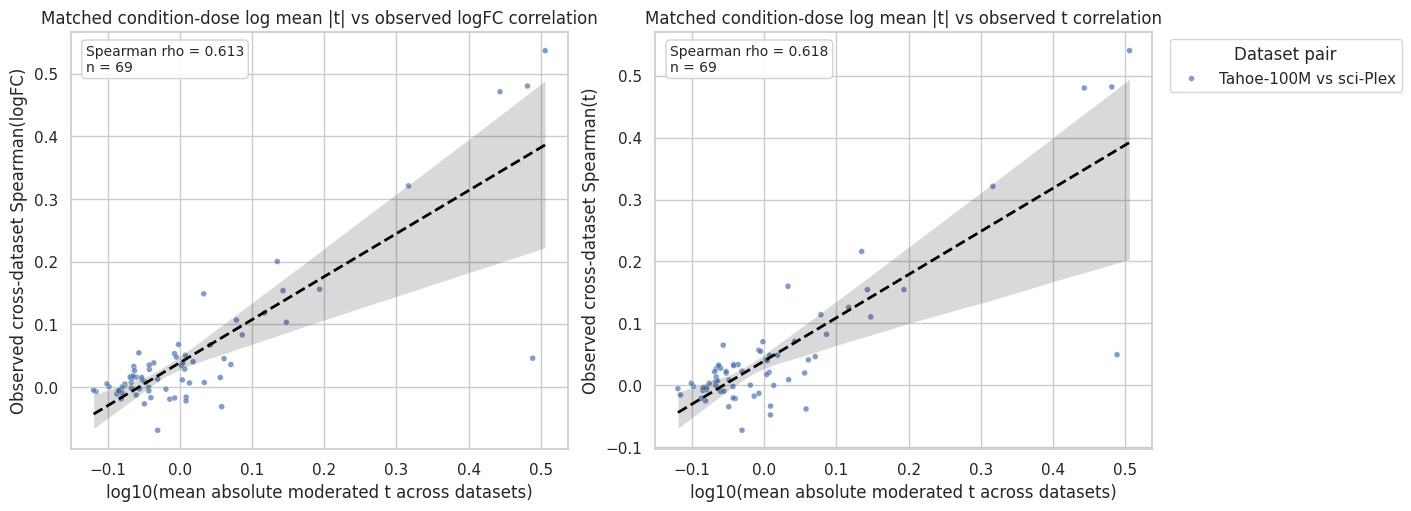

In [22]:
plot_frame = matched_condition_t_strength_summary.copy()
plot_frame = plot_frame.loc[
    np.isfinite(plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float))
    & (plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float) > 0)
].copy()
plot_frame["log10_mean_pair_mean_abs_t"] = np.log10(plot_frame["mean_pair_mean_abs_t"].to_numpy(dtype=float))
plot_frame["dataset_pair"] = plot_frame["dataset_a"].map(pretty_label) + " vs " + plot_frame["dataset_b"].map(pretty_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.scatterplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_logfc",
    hue="dataset_pair",
    alpha=0.7,
    s=18,
    ax=axes[0],
)
sns.regplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_logfc",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0, "linestyle": "--"},
    ax=axes[0],
)
logfc_rho = safe_column_spearman(plot_frame, "log10_mean_pair_mean_abs_t", "mean_observed_spearman_logfc")
logfc_subset = plot_frame[["log10_mean_pair_mean_abs_t", "mean_observed_spearman_logfc"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[0].text(
    0.03,
    0.97,
    f"Spearman rho = {logfc_rho:.3f}\nn = {len(logfc_subset):,}",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[0].set_title("Matched condition-dose log mean |t| vs observed logFC correlation")
axes[0].set_xlabel("log10(mean absolute moderated t across datasets)")
axes[0].set_ylabel("Observed cross-dataset Spearman(logFC)")

sns.scatterplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_t",
    hue="dataset_pair",
    alpha=0.7,
    s=18,
    ax=axes[1],
)
sns.regplot(
    data=plot_frame,
    x="log10_mean_pair_mean_abs_t",
    y="mean_observed_spearman_t",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2.0, "linestyle": "--"},
    ax=axes[1],
)
t_rho = safe_column_spearman(plot_frame, "log10_mean_pair_mean_abs_t", "mean_observed_spearman_t")
t_subset = plot_frame[["log10_mean_pair_mean_abs_t", "mean_observed_spearman_t"]].replace([np.inf, -np.inf], np.nan).dropna()
axes[1].text(
    0.03,
    0.97,
    f"Spearman rho = {t_rho:.3f}\nn = {len(t_subset):,}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[1].set_title("Matched condition-dose log mean |t| vs observed t correlation")
axes[1].set_xlabel("log10(mean absolute moderated t across datasets)")
axes[1].set_ylabel("Observed cross-dataset Spearman(t)")

handles, labels = axes[1].get_legend_handles_labels()
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
axes[1].legend(handles=handles, labels=labels, title="Dataset pair", bbox_to_anchor=(1.02, 1), loc="upper left")

t_strength_scatter_path = OUTPUT_DIR / "matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter.pdf"
fig.savefig(t_strength_scatter_path, bbox_inches="tight")
print(f"Saved plot to {t_strength_scatter_path}")

t_strength_scatter_description_path = OUTPUT_DIR / "matched_condition_log10_mean_abs_t_vs_observed_spearman_scatter_description.txt"
description_lines = [
    "Plot: matched-condition perturbation strength vs cross-dataset signature similarity.",
    "",
    f"Source table: {matched_pair_metrics_path}",
    f"Output plot: {t_strength_scatter_path}",
    f"Number of plotted matched condition-dose points: {len(plot_frame):,}",
    "",
    "Generation steps:",
    "1. Start from matched_sample_pair_metrics.tsv, which contains precomputed pairwise signature-similarity metrics for matched sample pairs across datasets.",
    "2. Aggregate sample-pair rows to matched condition-dose rows grouped by dataset_a, dataset_b, cell_type, time_key, pubchem_cid, left_dose_key, right_dose_key, and matched_condition_key.",
    "3. For each matched condition-dose row, average pair_mean_abs_t, observed_spearman_logfc, and observed_spearman_t over the available matched sample pairs.",
    "4. Keep rows with finite, positive mean_pair_mean_abs_t and plot log10(mean_pair_mean_abs_t) on the x-axis.",
    "5. Draw two scatter panels: observed cross-dataset Spearman(logFC) on the left and observed cross-dataset Spearman(moderated t) on the right.",
    "6. Color points by dataset pair and overlay a dashed black linear regression trend line for visual orientation.",
    "7. Report Spearman rho in each panel using the plotted matched condition-dose points, after dropping non-finite x/y values.",
    "",
    "What the plot shows:",
    f"- Left panel: association between log10 mean absolute moderated t and observed cross-dataset Spearman(logFC); Spearman rho = {logfc_rho:.3f}, n = {len(logfc_subset):,}.",
    f"- Right panel: association between log10 mean absolute moderated t and observed cross-dataset Spearman(moderated t); Spearman rho = {t_rho:.3f}, n = {len(t_subset):,}.",
    "- Higher mean absolute moderated t corresponds to stronger perturbation signal across the two datasets for a matched compound, cell type, time, and dose pair.",
    "- The positive Spearman correlations indicate that stronger perturbation signals tend to be more reproducible across datasets, but the scatter remains broad, so t-strength is only a partial explanation of cross-dataset similarity.",
    "- The figure is descriptive and uses already precomputed signature-similarity outputs; it does not recompute signatures or add uncertainty intervals.",
]
t_strength_scatter_description_path.write_text("\n".join(description_lines) + "\n")
print(f"Saved plot description to {t_strength_scatter_description_path}")
plt.show()


Optional cleanup:

```python
close_all_line_sources()
```


**Dataset-Pair Heatmaps**

These heatmaps summarize the dataset-pair means for `Spearman(logFC)` at three levels:
- observed cross-dataset score
- pair baseline score
- observed minus baseline pair score

They use the same dataset labels and lower-triangular layout as [plot_overlap_heatmaps.ipynb](./plot_overlap_heatmaps.ipynb). The diagonal is masked because these are cross-dataset summaries only.

In [23]:
HEATMAP_OUTPUT_PATHS = {
    "mean_observed_spearman_logfc": OUTPUT_DIR / "dataset_pair_mean_observed_spearman_logfc_heatmap.pdf",
    "mean_baseline_pair_spearman_logfc": OUTPUT_DIR / "dataset_pair_mean_baseline_pair_spearman_logfc_heatmap.pdf",
    "mean_delta_pair_mean_spearman_logfc": OUTPUT_DIR / "dataset_pair_mean_delta_pair_mean_spearman_logfc_heatmap.pdf",
}


build_symmetric_pair_metric_matrix = cross_source_core.build_symmetric_pair_metric_matrix


heatmap_dataset_order = [dataset_name for dataset_name in DATASET_ORDER if dataset_name in active_datasets]

observed_baseline_values = pd.concat(
    [
        pair_metric_summary["mean_observed_spearman_logfc"],
        pair_metric_summary["mean_baseline_pair_spearman_logfc"],
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan)
observed_baseline_values = observed_baseline_values.dropna()
if observed_baseline_values.empty:
    observed_baseline_vmin = None
    observed_baseline_vmax = None
else:
    observed_baseline_vmin = float(observed_baseline_values.min())
    observed_baseline_vmax = float(observed_baseline_values.max())


delta_values = (
    pair_metric_baseline_adjusted_summary["mean_delta_pair_mean_spearman_logfc"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
if delta_values.empty:
    delta_abs_max = None
else:
    delta_abs_max = float(np.nanmax(np.abs(delta_values.to_numpy(dtype=float))))



def plot_pair_metric_heatmap(
    summary_frame: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str,
    output_path: Path,
    *,
    dataset_order: Optional[list[str]] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    center: Optional[float] = None,
    cbar_label: Optional[str] = None,
):
    dataset_order = dataset_order or heatmap_dataset_order
    matrix = build_symmetric_pair_metric_matrix(summary_frame, value_col, dataset_order)
    display_matrix = matrix.rename(index=pretty_label, columns=pretty_label).iloc[1:, :-1]
    mask = np.triu(np.ones(display_matrix.shape, dtype=bool), k=1)

    fig_width = max(5.5, 1.35 * len(display_matrix.columns))
    fig_height = max(4.5, 1.15 * len(display_matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    sns.heatmap(
        display_matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.85},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.grid(False)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {output_path}")


print("Heatmap datasets:", ", ".join(pretty_label(dataset_name) for dataset_name in heatmap_dataset_order))


Heatmap datasets: Tahoe-100M, sci-Plex


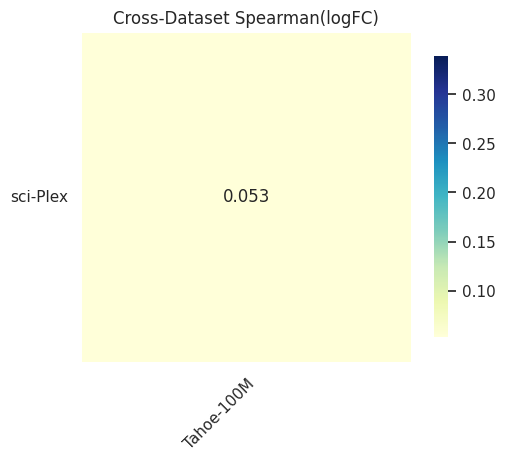

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_mean_observed_spearman_logfc_heatmap.pdf


In [24]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_observed_spearman_logfc",
    title="Cross-Dataset Spearman(logFC)",
    cmap="YlGnBu",
    output_path=HEATMAP_OUTPUT_PATHS["mean_observed_spearman_logfc"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Mean observed Spearman(logFC)",
)


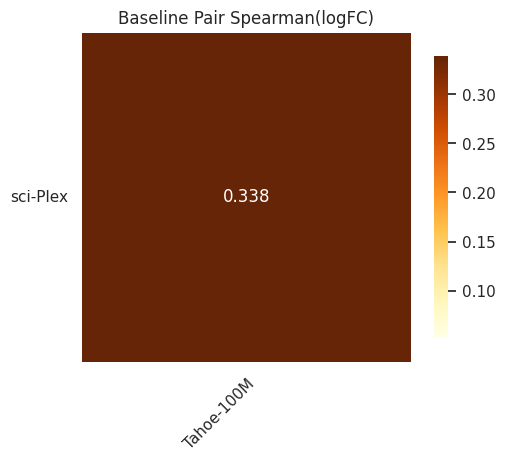

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_mean_baseline_pair_spearman_logfc_heatmap.pdf


In [25]:
plot_pair_metric_heatmap(
    pair_metric_summary,
    value_col="mean_baseline_pair_spearman_logfc",
    title="Baseline Pair Spearman(logFC)",
    cmap="YlOrBr",
    output_path=HEATMAP_OUTPUT_PATHS["mean_baseline_pair_spearman_logfc"],
    dataset_order=heatmap_dataset_order,
    vmin=observed_baseline_vmin,
    vmax=observed_baseline_vmax,
    cbar_label="Mean baseline pair Spearman(logFC)",
)


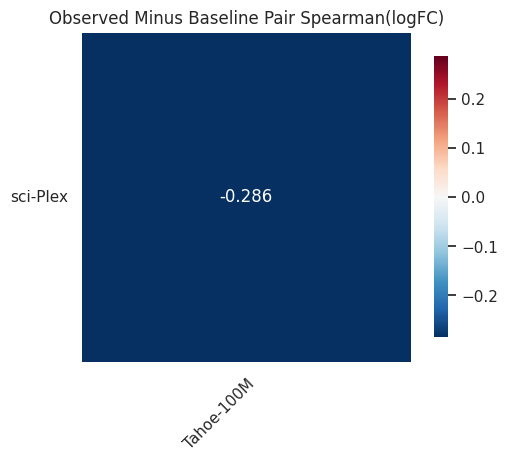

Saved heatmap to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_mean_delta_pair_mean_spearman_logfc_heatmap.pdf


In [26]:
plot_pair_metric_heatmap(
    pair_metric_baseline_adjusted_summary,
    value_col="mean_delta_pair_mean_spearman_logfc",
    title="Observed Minus Baseline Pair Spearman(logFC)",
    cmap="RdBu_r",
    output_path=HEATMAP_OUTPUT_PATHS["mean_delta_pair_mean_spearman_logfc"],
    dataset_order=heatmap_dataset_order,
    vmin=None if delta_abs_max is None else -delta_abs_max,
    vmax=None if delta_abs_max is None else delta_abs_max,
    center=0.0,
    cbar_label="Mean delta Spearman(logFC)",
)


## Per-peer and target-side baselines for all-gene logFC Spearman

This section mirrors the peer-baseline analysis in
[overlap_group_rep_deg_metrics_reviewer_additions.ipynb](./overlap_group_rep_deg_metrics_reviewer_additions.ipynb)
for the all-gene `logFC` Spearman metric, which is the whole-signature counterpart of the
DEG-restricted agreement tables.

Everything above is unchanged. The same matched sample pairs are rescored against four
baselines -- `source_centroid` (the published one, recomputed as a parity check),
`target_centroid` (the same mean built from the other dataset's peers), `source_peer`
(every own-dataset peer scored separately), and `target_peer` (every other-dataset peer
scored separately) -- with the mean, standard deviation, fraction of peer scores below the
observed score, and the add-one corrected percentile `(1 + #{m(i, x) < m(i, j)}) / (K + 1)`
reported for the per-peer variants.

In [27]:
import importlib
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import scripts.notebook_cache as notebook_cache_module
import scripts.peer_baselines as peer_baselines_module

# Support resuming this section in a kernel that imported the pre-optimization helpers.
importlib.reload(notebook_cache_module)
importlib.reload(peer_baselines_module)
cached_frame = notebook_cache_module.cached_frame
cache_summary = notebook_cache_module.cache_summary
resumable_context_frame = notebook_cache_module.resumable_context_frame
stable_json_fingerprint = notebook_cache_module.stable_json_fingerprint
frame_identity_fingerprint = notebook_cache_module.frame_identity_fingerprint

from scripts.peer_baselines import (
    empty_peer_score_summary,
    prepare_spearman_rows,
    select_peer_indices,
    spearman_against_prepared_peers,
    summarize_peer_scores,
)

# Table 6 reports all-gene logFC Spearman on the pairwise shared gene set.
PEER_BASELINE_VARIANTS = (
    "source_centroid",
    "target_centroid",
    "source_peer",
    "target_peer",
)
MAX_BASELINE_PEERS: Optional[int] = 512
PEER_SAMPLING_SEED = 20260505


baseline_peer_stratum = cross_source_core.line_source_stratum_arrays


def baseline_peer_selection(
    source: LineSource,
    obs_id: str,
    *,
    pubchem_cid: str,
    dose_key: str,
    time_key: str,
) -> tuple[SignatureStratum, np.ndarray, int]:
    selection = cross_source_core.select_line_source_peers(
        source,
        obs_id,
        pubchem_cid=pubchem_cid,
        dose_key=dose_key,
        time_key=time_key,
        max_peers=MAX_BASELINE_PEERS,
        sampling_seed=PEER_SAMPLING_SEED,
    )
    return (
        selection.stratum,
        selection.row_indices,
        selection.total_count,
    )


def baseline_peer_logfc_matrix(
    source: LineSource,
    obs_id: str,
    *,
    pubchem_cid: str,
    dose_key: str,
    time_key: str,
) -> tuple[np.ndarray, int, int]:
    stratum, chosen, n_total = baseline_peer_selection(
        source,
        obs_id,
        pubchem_cid=pubchem_cid,
        dose_key=dose_key,
        time_key=time_key,
    )
    return stratum.values[chosen], n_total, int(chosen.size)


def compute_peer_baseline_record(match_row: pd.Series) -> dict[str, object]:
    """Score one matched sample pair's all-gene logFC Spearman against four baselines.

      source_centroid -- the published baseline: mean of the sample's own-dataset peers.
      target_centroid -- the same mean built in the other dataset.
      source_peer     -- every own-dataset peer scored separately.
      target_peer     -- every other-dataset peer scored separately.
    """
    dataset_a = str(match_row["dataset_a"])
    dataset_b = str(match_row["dataset_b"])
    cell_type = str(match_row["cell_type"])
    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(left_source, right_source)
    if shared_genes.size < 2:
        raise ValueError(
            f"Fewer than two shared genes for {dataset_a} vs {dataset_b} / {cell_type}"
        )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])
    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_logfc = left_source.get_vector(left_obs_id, "logFC", **left_lookup)[left_gene_pos]
    right_logfc = right_source.get_vector(right_obs_id, "logFC", **right_lookup)[right_gene_pos]

    left_centroid_full = left_source.get_baseline_vector(left_obs_id, "logFC", **left_lookup)
    right_centroid_full = right_source.get_baseline_vector(right_obs_id, "logFC", **right_lookup)
    left_centroid = None if left_centroid_full is None else np.asarray(left_centroid_full, dtype=np.float32)[left_gene_pos]
    right_centroid = None if right_centroid_full is None else np.asarray(right_centroid_full, dtype=np.float32)[right_gene_pos]

    left_peer_stratum, left_peer_rows, left_n_total_peers = baseline_peer_selection(
        left_source,
        left_obs_id,
        **left_lookup,
    )
    right_peer_stratum, right_peer_rows, right_n_total_peers = baseline_peer_selection(
        right_source,
        right_obs_id,
        **right_lookup,
    )
    left_n_scored_peers = int(left_peer_rows.size)
    right_n_scored_peers = int(right_peer_rows.size)
    left_peers = left_peer_stratum.values[left_peer_rows][:, left_gene_pos]
    right_peers = right_peer_stratum.values[right_peer_rows][:, right_gene_pos]
    prepared_peer_matrices = {
        "left": (left_peer_stratum.prepared_spearman(left_gene_pos), left_peer_rows),
        "right": (right_peer_stratum.prepared_spearman(right_gene_pos), right_peer_rows),
    }

    # The peer set must be exactly the set the published centroid averaged. Comparing
    # counts checks that membership without recomputing the centroid mean per pair, and it
    # keeps working when MAX_BASELINE_PEERS caps how many peers are scored.
    for side, source, obs_id, lookup, n_total in (
        ("left", left_source, left_obs_id, left_lookup, left_n_total_peers),
        ("right", right_source, right_obs_id, right_lookup, right_n_total_peers),
    ):
        expected_peers = int(source.baseline_peer_count(obs_id, **lookup))
        if int(n_total) != expected_peers:
            raise AssertionError(
                f"Peer set does not match the published centroid for {side} side of "
                f"{dataset_a} vs {dataset_b} / {cell_type} / {pubchem_cid}: "
                f"{int(n_total)} peers vs {expected_peers} averaged by get_baseline_vector."
            )

    observed = signed_spearman(left_logfc, right_logfc)
    record: dict[str, object] = {
        **match_row.to_dict(),
        "n_common_genes": int(shared_genes.size),
        "left_peer_total_count": left_n_total_peers,
        "right_peer_total_count": right_n_total_peers,
        "left_peer_scored_count": left_n_scored_peers,
        "right_peer_scored_count": right_n_scored_peers,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "pb_observed_spearman_logfc": observed,
    }

    side_specs = {
        "left": {
            "sample_logfc": left_logfc,
            "source_centroid": left_centroid,
            "target_centroid": right_centroid,
            "source_peers": left_peers,
            "target_peers": right_peers,
        },
        "right": {
            "sample_logfc": right_logfc,
            "source_centroid": right_centroid,
            "target_centroid": left_centroid,
            "source_peers": right_peers,
            "target_peers": left_peers,
        },
    }

    for variant in PEER_BASELINE_VARIANTS:
        side_values: list[float] = []
        side_sds: list[float] = []
        side_fractions: list[float] = []
        side_percentiles: list[float] = []
        for side, spec in side_specs.items():
            column_stem = f"pb_{variant}_spearman_logfc_{side}"
            if variant.endswith("_centroid"):
                centroid = spec[variant]
                value = (
                    float("nan")
                    if centroid is None
                    else signed_spearman(spec["sample_logfc"], centroid)
                )
                record[column_stem] = value
                side_values.append(value)
                continue

            peer_matrix = spec["source_peers" if variant == "source_peer" else "target_peers"]
            if peer_matrix.shape[0] == 0:
                record.update(empty_peer_score_summary(column_stem))
                side_values.append(float("nan"))
                side_sds.append(float("nan"))
                side_fractions.append(float("nan"))
                side_percentiles.append(float("nan"))
                continue
            prepared_peers, prepared_peer_rows = prepared_peer_matrices[
                "left" if peer_matrix is left_peers else "right"
            ]
            peer_scores = spearman_against_prepared_peers(
                spec["sample_logfc"], prepared_peers, row_indices=prepared_peer_rows
            )
            summary = summarize_peer_scores(observed, peer_scores, column_stem)
            record.update(summary)
            side_values.append(summary[f"{column_stem}_mean_score"])
            side_sds.append(summary[f"{column_stem}_sd_score"])
            side_fractions.append(summary[f"{column_stem}_fraction_below_observed"])
            side_percentiles.append(summary[f"{column_stem}_corrected_percentile"])

        pair_stem = f"pb_{variant}_spearman_logfc_pair"
        pair_value = mean_available(side_values)
        record[pair_stem] = pair_value
        record[f"pb_delta_vs_{variant}_spearman_logfc"] = (
            float("nan")
            if (pd.isna(observed) or pd.isna(pair_value))
            else float(observed - pair_value)
        )
        if not variant.endswith("_centroid"):
            record[f"{pair_stem}_sd_score"] = mean_available(side_sds)
            record[f"{pair_stem}_fraction_below_observed"] = mean_available(side_fractions)
            record[f"{pair_stem}_corrected_percentile"] = mean_available(side_percentiles)

    return record


print(f"All-gene logFC per-peer baselines configured with max_peers={MAX_BASELINE_PEERS}")

All-gene logFC per-peer baselines configured with max_peers=512


In [28]:
peer_baseline_unresolved: list[dict[str, object]] = []

PEER_BASELINE_INPUT_FINGERPRINT = stable_json_fingerprint(
    {
        "version": "signature-peer-v5",
        "cap": MAX_BASELINE_PEERS,
        "seed": PEER_SAMPLING_SEED,
        "matched_metrics": frame_identity_fingerprint(
            matched_pair_metrics,
            context_join_columns + ["pubchem_cid", "left_obs_id", "right_obs_id"],
        ),
        "sources": sorted(
            (
                str(path.resolve()),
                int(path.stat().st_size),
                int(path.stat().st_mtime_ns),
            )
            for dataset_name, cell_type in matched_pairs[["dataset_a", "cell_type"]]
            .drop_duplicates()
            .itertuples(index=False, name=None)
            for path in [resolve_line_path(str(dataset_name), str(cell_type))]
        )
        + sorted(
            (
                str(path.resolve()),
                int(path.stat().st_size),
                int(path.stat().st_mtime_ns),
            )
            for dataset_name, cell_type in matched_pairs[["dataset_b", "cell_type"]]
            .drop_duplicates()
            .itertuples(index=False, name=None)
            for path in [resolve_line_path(str(dataset_name), str(cell_type))]
        ),
    }
)
peer_baseline_contexts = [
    (tuple(str(value) for value in context_key), group.copy())
    for context_key, group in matched_pairs.groupby(context_join_columns, sort=False)
]


def build_peer_baseline_context(context_item) -> pd.DataFrame:
    context_key, group = context_item
    dataset_a, dataset_b, cell_type, time_key, left_dose_key, right_dose_key = context_key
    print(
        f"Peer baselines for {pretty_label(dataset_a)} vs {pretty_label(dataset_b)} / {cell_type} / "
        f"time={time_key} / doses={left_dose_key} vs {right_dose_key}: {len(group)} matched sample pairs",
        flush=True,
    )
    records: list[dict[str, object]] = []
    row_progress = notebook_cache_module.ProgressReporter(
        total=len(group),
        label="peer_baseline_rows",
        every=100,
        min_interval_seconds=20.0,
    )
    for _, match_row in group.iterrows():
        try:
            records.append(compute_peer_baseline_record(match_row))
        except KeyError as exc:
            peer_baseline_unresolved.append({**match_row.to_dict(), "error": str(exc)})
        finally:
            row_progress.update(detail=f"{dataset_a} vs {dataset_b} / {cell_type}")
    return pd.DataFrame(records)


def build_peer_baselines() -> pd.DataFrame:
    return resumable_context_frame(
        "peer_baselines",
        OUTPUT_DIR / ".checkpoints" / "peer_baselines",
        peer_baseline_contexts,
        context_key=lambda item: item[0],
        build_context=build_peer_baseline_context,
        fingerprint=PEER_BASELINE_INPUT_FINGERPRINT,
        context_label=lambda item: " / ".join(item[0]),
    )


matched_pair_peer_baselines_path = OUTPUT_DIR / "matched_sample_pair_peer_baselines.tsv"
matched_pair_peer_baselines = cached_frame(
    "peer_baselines",
    matched_pair_peer_baselines_path,
    build_peer_baselines,
    fingerprint=PEER_BASELINE_INPUT_FINGERPRINT,
    required_columns=[
        "pb_observed_spearman_logfc",
        "pb_source_peer_spearman_logfc_pair",
        "pb_source_peer_spearman_logfc_pair_sd_score",
        "pb_target_peer_spearman_logfc_pair",
    ],
)
if matched_pair_peer_baselines.empty:
    raise ValueError("No matched sample pairs could be scored against the per-peer baselines.")

print(f"Scored {len(matched_pair_peer_baselines):,} matched sample pairs")

if peer_baseline_unresolved:
    peer_baseline_unresolved_frame = pd.DataFrame(peer_baseline_unresolved)
    peer_baseline_unresolved_path = OUTPUT_DIR / "unresolved_peer_baseline_pairs.tsv"
    peer_baseline_unresolved_frame.to_csv(peer_baseline_unresolved_path, sep="\t", index=False)
    print(
        f"Skipped {len(peer_baseline_unresolved_frame):,} matched sample pairs; "
        f"saved details to {peer_baseline_unresolved_path}"
    )

# Parity: the recomputed observed and source-centroid columns must reproduce the published
# ones, so any change in the reported deltas comes from the new baselines only.
peer_baseline_join_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_obs_id",
    "right_obs_id",
    "left_dose_key",
    "right_dose_key",
]
parity_column_pairs = [
    ("pb_observed_spearman_logfc", "observed_spearman_logfc"),
    ("pb_source_centroid_spearman_logfc_left", "left_baseline_spearman_logfc"),
    ("pb_source_centroid_spearman_logfc_right", "right_baseline_spearman_logfc"),
    ("pb_source_centroid_spearman_logfc_pair", "baseline_pair_mean_spearman_logfc"),
]
parity_frame = matched_pair_peer_baselines.merge(
    matched_pair_metrics[peer_baseline_join_columns + [published for _, published in parity_column_pairs]],
    on=peer_baseline_join_columns,
    how="inner",
    validate="one_to_one",
)
if len(parity_frame) != len(matched_pair_peer_baselines):
    raise AssertionError(
        f"Parity join matched {len(parity_frame):,} of {len(matched_pair_peer_baselines):,} peer-baseline rows."
    )

parity_rows: list[dict[str, object]] = []
for recomputed_column, published_column in parity_column_pairs:
    recomputed = parity_frame[recomputed_column].to_numpy(dtype=np.float64)
    published = parity_frame[published_column].to_numpy(dtype=np.float64)
    both_finite = np.isfinite(recomputed) & np.isfinite(published)
    parity_rows.append(
        {
            "recomputed_column": recomputed_column,
            "published_column": published_column,
            "n_both_finite": int(both_finite.sum()),
            "n_finite_mismatch": int(np.sum(np.isfinite(recomputed) != np.isfinite(published))),
            "max_abs_diff": (
                float(np.max(np.abs(recomputed[both_finite] - published[both_finite])))
                if both_finite.any()
                else float("nan")
            ),
        }
    )
peer_baseline_parity = pd.DataFrame(parity_rows)
display(peer_baseline_parity)

if int(peer_baseline_parity["n_finite_mismatch"].sum()) > 0:
    raise AssertionError("Recomputed and published columns disagree on which rows are defined.")
worst_parity_diff = float(np.nanmax(peer_baseline_parity["max_abs_diff"].to_numpy(dtype=np.float64)))
if worst_parity_diff > 1e-6:
    raise AssertionError(
        f"Recomputed source-centroid parity check failed with max abs diff {worst_parity_diff:.3g}."
    )
print(f"Parity check passed; largest absolute difference {worst_parity_diff:.3g}.")

[peer_baselines] computing context 1/3: tahoe / sciplex / CVCL_0023 / 24 / 0.05 / 0.1
Peer baselines for Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=0.05 vs 0.1: 52 matched sample pairs
[peer_baseline_rows] 52/52 (100.0%) | elapsed 00:11 | 4.89/s | ETA 00:00 | tahoe vs sciplex / CVCL_0023
[peer_baselines] 1/3 (33.3%) | elapsed 00:11 | 0.09/s | ETA 00:21 | 0 reloaded, 1 computed
[peer_baselines] computing context 2/3: tahoe / sciplex / CVCL_0023 / 24 / 0.5 / 1
Peer baselines for Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=0.5 vs 1: 52 matched sample pairs
[peer_baseline_rows] 52/52 (100.0%) | elapsed 00:11 | 4.94/s | ETA 00:00 | tahoe vs sciplex / CVCL_0023
[peer_baselines] 2/3 (66.7%) | elapsed 00:21 | 0.09/s | ETA 00:11 | 0 reloaded, 2 computed
[peer_baselines] computing context 3/3: tahoe / sciplex / CVCL_0023 / 24 / 5 / 10
Peer baselines for Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=5 vs 10: 66 matched sample pairs
[peer_baseline_rows] 66/66 (100.0%) | e

,recomputed_column,published_column,n_both_finite,n_finite_mismatch,max_abs_diff
0,pb_observed_spearman_logfc,observed_spearman_logfc,170,0,0.0
1,pb_source_centroid_spearman_logfc_left,left_baseline_spearman_logfc,170,0,0.0
2,pb_source_centroid_spearman_logfc_right,right_baseline_spearman_logfc,170,0,0.0
3,pb_source_centroid_spearman_logfc_pair,baseline_pair_mean_spearman_logfc,170,0,0.0


Parity check passed; largest absolute difference 0.


In [29]:
peer_baseline_value_columns = [
    column_name
    for column_name in matched_pair_peer_baselines.columns
    if column_name.startswith("pb_")
    or column_name.endswith("_peer_total_count")
    or column_name.endswith("_peer_scored_count")
    or column_name == "n_common_genes"
]

peer_drug_line_time_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for column_name in peer_baseline_value_columns:
    peer_drug_line_time_agg[f"mean_{column_name}"] = (column_name, "mean")

peer_drug_line_time_summary = (
    matched_pair_peer_baselines.groupby(drug_line_time_group_columns, as_index=False)
    .agg(**peer_drug_line_time_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)

peer_summary_mean_columns = [
    column_name
    for column_name in peer_drug_line_time_summary.columns
    if column_name.startswith("mean_")
]

peer_pair_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in peer_summary_mean_columns:
    peer_pair_agg[column_name] = (column_name, "mean")

peer_pair_summary = (
    peer_drug_line_time_summary.groupby(["dataset_a", "dataset_b"], as_index=False)
    .agg(**peer_pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)

peer_line_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column_name in peer_summary_mean_columns:
    peer_line_agg[column_name] = (column_name, "mean")

peer_line_summary = (
    peer_drug_line_time_summary.groupby(["dataset_a", "dataset_b", "cell_type"], as_index=False)
    .agg(**peer_line_agg)
    .sort_values(["dataset_a", "dataset_b", "cell_type"])
    .reset_index(drop=True)
)

for filename, frame in {
    "matched_drug_line_time_peer_baseline_summary.tsv": peer_drug_line_time_summary,
    "dataset_pair_peer_baseline_summary.tsv": peer_pair_summary,
    "dataset_pair_line_peer_baseline_summary.tsv": peer_line_summary,
}.items():
    output_path = OUTPUT_DIR / filename
    frame.to_csv(output_path, sep="\t", index=False)
    print(f"Saved peer-baseline summary to {output_path}")

peer_baseline_ci_stems = ["pb_observed_spearman_logfc"]
for variant in PEER_BASELINE_VARIANTS:
    peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair")
    peer_baseline_ci_stems.append(f"pb_delta_vs_{variant}_spearman_logfc")
    if not variant.endswith("_centroid"):
        peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair_sd_score")
        peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair_fraction_below_observed")
        peer_baseline_ci_stems.append(f"pb_{variant}_spearman_logfc_pair_corrected_percentile")

peer_baseline_ci_metrics = {stem: f"mean_{stem}" for stem in peer_baseline_ci_stems}
missing_ci_columns = sorted(
    set(peer_baseline_ci_metrics.values()) - set(peer_drug_line_time_summary.columns)
)
if missing_ci_columns:
    raise KeyError(f"Missing peer-baseline CI columns: {missing_ci_columns}")

def build_peer_ci() -> pd.DataFrame:
    peer_baseline_cluster_bca_ci = pd.concat(
        [
            cluster_bca_nested_mean_ci_table(
                peer_drug_line_time_summary,
                group_cols=["dataset_a", "dataset_b"],
                metric_cols=peer_baseline_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="peer_baseline_dataset_pair",
            ),
            cluster_bca_nested_mean_ci_table(
                peer_drug_line_time_summary,
                group_cols=["dataset_a", "dataset_b", "cell_type"],
                metric_cols=peer_baseline_ci_metrics,
                cluster_col="pubchem_cid",
                n_boot=BOOTSTRAP_ITERATIONS,
                seed=BOOTSTRAP_RANDOM_SEED,
                summary_level="peer_baseline_dataset_pair_line",
            ),
        ],
        ignore_index=True,
    )
    return peer_baseline_cluster_bca_ci


peer_baseline_cluster_bca_ci_path = OUTPUT_DIR / "peer_baseline_cluster_bca_ci.tsv"
peer_baseline_cluster_bca_ci = cached_frame(
    "peer_ci",
    peer_baseline_cluster_bca_ci_path,
    build_peer_ci,
    fingerprint=(
        f"signature-peer-ci-v2|source={PEER_BASELINE_INPUT_FINGERPRINT}"
        f"|boot={BOOTSTRAP_ITERATIONS}|seed={BOOTSTRAP_RANDOM_SEED}"
    ),
)

peer_baseline_ci_ranges = summarize_ci_half_width_ranges(peer_baseline_cluster_bca_ci)
peer_baseline_ci_ranges_path = OUTPUT_DIR / "peer_baseline_cluster_bca_ci_ranges.tsv"
peer_baseline_ci_ranges.to_csv(peer_baseline_ci_ranges_path, sep="\t", index=False)
print(f"Saved peer-baseline CI half-width ranges to {peer_baseline_ci_ranges_path}")


format_ci_cell = cross_source_core.format_ci_cell


pair_level_ci = peer_baseline_cluster_bca_ci.loc[
    peer_baseline_cluster_bca_ci["summary_level"] == "peer_baseline_dataset_pair"
].copy()
pair_level_ci["cell"] = pair_level_ci.apply(format_ci_cell, axis=1)
ci_lookup = {
    (str(row["dataset_a"]), str(row["dataset_b"]), str(row["metric"])): str(row["cell"])
    for _, row in pair_level_ci.iterrows()
}

rebuttal_rows: list[dict[str, object]] = []
for _, pair_row in peer_pair_summary.iterrows():
    dataset_a = str(pair_row["dataset_a"])
    dataset_b = str(pair_row["dataset_b"])
    record: dict[str, object] = {
        "dataset_a": pretty_label(dataset_a),
        "dataset_b": pretty_label(dataset_b),
        "metric": "all_gene_spearman_logfc",
        "n_compounds": int(pair_row["n_matching_drugs"]),
        "n_drug_line_times": int(pair_row["n_matching_drug_line_times"]),
        "observed": ci_lookup.get((dataset_a, dataset_b, "pb_observed_spearman_logfc"), ""),
    }
    for variant in PEER_BASELINE_VARIANTS:
        record[variant] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_{variant}_spearman_logfc_pair"), ""
        )
        record[f"delta_vs_{variant}"] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_delta_vs_{variant}_spearman_logfc"), ""
        )
    for variant in ("source_peer", "target_peer"):
        record[f"{variant}_fraction_below_observed"] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_{variant}_spearman_logfc_pair_fraction_below_observed"), ""
        )
        record[f"{variant}_corrected_percentile"] = ci_lookup.get(
            (dataset_a, dataset_b, f"pb_{variant}_spearman_logfc_pair_corrected_percentile"), ""
        )
    record["mean_peers_source"] = float(
        np.nanmean(
            [
                pair_row.get("mean_left_peer_scored_count", np.nan),
                pair_row.get("mean_right_peer_scored_count", np.nan),
            ]
        )
    )
    rebuttal_rows.append(record)

peer_baseline_rebuttal_table = pd.DataFrame(rebuttal_rows)
peer_baseline_rebuttal_table_path = OUTPUT_DIR / "peer_baseline_rebuttal_table.tsv"
peer_baseline_rebuttal_table.to_csv(peer_baseline_rebuttal_table_path, sep="\t", index=False)
print(f"Saved rebuttal-ready peer-baseline table to {peer_baseline_rebuttal_table_path}")
display(peer_baseline_rebuttal_table)

display(cache_summary())

Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/matched_drug_line_time_peer_baseline_summary.tsv
Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_peer_baseline_summary.tsv
Saved peer-baseline summary to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/dataset_pair_line_peer_baseline_summary.tsv
[peer_ci] computed and saved 30 rows to peer_baseline_cluster_bca_ci.tsv
Saved peer-baseline CI half-width ranges to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/peer_baseline_cluster_bca_ci_ranges.tsv
Saved rebuttal-ready peer-baseline table to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/taho

,dataset_a,dataset_b,metric,n_compounds,n_drug_line_times,observed,source_centroid,delta_vs_source_centroid,target_centroid,delta_vs_target_centroid,source_peer,delta_vs_source_peer,target_peer,delta_vs_target_peer,source_peer_fraction_below_observed,source_peer_corrected_percentile,target_peer_fraction_below_observed,target_peer_corrected_percentile,mean_peers_source
0,Tahoe-100M,sci-Plex,all_gene_spearman_logfc,23,23,"0.053 [0.024, 0.119]","0.338 [0.314, 0.357]","-0.286 [-0.317, -0.227]","0.016 [0.003, 0.032]","0.036 [0.013, 0.087]","0.134 [0.125, 0.142]","-0.082 [-0.111, -0.012]","0.003 [-0.002, 0.008]","0.050 [0.022, 0.112]","0.324 [0.262, 0.427]","0.327 [0.264, 0.437]","0.671 [0.603, 0.754]","0.672 [0.603, 0.756]",278.440217


,stage,status
0,peer_baselines,computed
1,peer_ci,computed


## W4: per-gene population standardization at two scopes

This additive sensitivity analysis keeps every raw-logFC result above unchanged. For each
dataset, it fits gene-wise population statistics both within each cellular context and
across all eligible cell types (`ddof=0`), then reports both transforms before computing
Table 6 all-gene logFC Spearman.

The same matched pairs, shared-gene sets, peer membership, peer cap, aggregation, and
compound-clustered BCa procedure are reused. Source/target centroids and individual peers
are all transformed with their own source-context statistics. This is a condition-level
analogue of the gene-wise population axis in L1000 Level 4, not a reconstruction of its
plate-level raw-expression pipeline.


In [30]:
import hashlib
import importlib
import json

import scripts.peer_baselines as peer_baselines_module
importlib.reload(peer_baselines_module)

from scripts.peer_baselines import (
    empty_peer_score_summary,
    finite_column_totals,
    prepare_spearman_rows,
    select_peer_indices,
    spearman_against_prepared_peers,
    summarize_peer_scores,
)
import scripts.population_zscore as population_zscore_module
importlib.reload(population_zscore_module)

from scripts.population_zscore import (
    ENGINE_VERSION as W4_ENGINE_VERSION,
    POPULATION_SCALE_VARIANTS,
    PopulationStatsCatalog,
    stats_qc_record,
)

W4_SCALE_VARIANTS = POPULATION_SCALE_VARIANTS
ACTIVE_W4_SCALE_VARIANT = W4_SCALE_VARIANTS[0]
W4_SMOKE_COMPARISON_POPULATION = os.environ.get(
    "CPB_W4_SMOKE_COMPARISON_POPULATION", ""
).strip().lower() in {"1", "true", "yes"}
W4_PRECOMPUTE_MODE = os.environ.get(
    "CPB_W4_PRECOMPUTE_MODE", "wait"
).strip().lower()
if W4_PRECOMPUTE_MODE not in {"stop", "wait", "lazy"}:
    raise ValueError("CPB_W4_PRECOMPUTE_MODE must be stop, wait, or lazy")
W4_PRECOMPUTE_POLL_SECONDS = float(
    os.environ.get("CPB_W4_PRECOMPUTE_POLL_SECONDS", "30")
)
W4_PRECOMPUTE_TIMEOUT_SECONDS = 60.0 * float(
    os.environ.get("CPB_W4_PRECOMPUTE_TIMEOUT_MINUTES", "720")
)
if W4_SMOKE_COMPARISON_POPULATION and TEST_DATASET_SUBSET is None:
    raise ValueError(
        "CPB_W4_SMOKE_COMPARISON_POPULATION is smoke-only and requires "
        "CPB_DATASET_SUBSET."
    )
W4_STATS_CACHE_ROOT = (
    OUTPUT_DIR / "w4_population_zscore_stats_smoke"
    if W4_SMOKE_COMPARISON_POPULATION
    else REPO_ROOT / "results" / "w4_population_zscore_stats"
)

W4_STATS_CATALOG = PopulationStatsCatalog(
    source_dataset_dirs=SOURCE_DATASET_DIRS,
    matched_lines=matched_lines,
    matched_dataset_names=matched_active_datasets,
    resolve_line_path=resolve_line_path,
    cache_root=W4_STATS_CACHE_ROOT,
    smoke_comparison_population=W4_SMOKE_COMPARISON_POPULATION,
    precompute_mode=W4_PRECOMPUTE_MODE,
    poll_seconds=W4_PRECOMPUTE_POLL_SECONDS,
    timeout_seconds=W4_PRECOMPUTE_TIMEOUT_SECONDS,
)
W4_POPULATION_POLICY = W4_STATS_CATALOG.population_policy
W4_STATS_BY_SOURCE = W4_STATS_CATALOG.stats_by_source
W4_POOLED_STATS_BY_DATASET = W4_STATS_CATALOG.pooled_stats_by_dataset
w4_dataset_population_source_paths = (
    W4_STATS_CATALOG.dataset_population_source_paths
)
get_w4_population_stats = lambda source: W4_STATS_CATALOG.get_stats(
    source,
    scale_variant=ACTIVE_W4_SCALE_VARIANT,
)

def w4_standardize_selected_vector(
    source: LineSource,
    values: np.ndarray,
    gene_positions: np.ndarray,
) -> np.ndarray:
    positions = np.asarray(gene_positions, dtype=np.int64)
    selected = np.asarray(values, dtype=np.float64).reshape(-1)[positions]
    return W4_STATS_CATALOG.standardize_aligned_vector(
        source,
        selected,
        positions,
        scale_variant=ACTIVE_W4_SCALE_VARIANT,
    )


def w4_standardize_selected_matrix(
    source: LineSource,
    values: np.ndarray,
    gene_positions: np.ndarray,
) -> np.ndarray:
    positions = np.asarray(gene_positions, dtype=np.int64)
    selected = np.atleast_2d(np.asarray(values, dtype=np.float64))[:, positions]
    return W4_STATS_CATALOG.standardize_aligned_matrix(
        source,
        selected,
        positions,
        scale_variant=ACTIVE_W4_SCALE_VARIANT,
    )



@dataclass(frozen=True)
class W4PreparedSignatureStratum:
    key: tuple[str, ...]
    compounds: np.ndarray
    raw_matrix: np.ndarray
    standardized_matrix: np.ndarray
    prepared_spearman: object
    total_sums: np.ndarray
    total_finite_counts: np.ndarray
    population_means: np.ndarray
    population_sds: np.ndarray
    population_valid_mask: np.ndarray


W4_SIGNATURE_STRATUM_CACHE: dict[tuple[str, ...], W4PreparedSignatureStratum] = {}
W4_SIGNATURE_STRATUM_CACHE_LIMIT = 4
W4_ASSERTED_CENTROID_STRATA: set[tuple[str, ...]] = set()


def get_w4_prepared_signature_stratum(
    source: LineSource,
    *,
    dose_key: str,
    time_key: str,
    gene_positions: np.ndarray,
) -> W4PreparedSignatureStratum:
    positions = np.asarray(gene_positions, dtype=np.int64)
    position_hash = hashlib.sha256(positions.tobytes()).hexdigest()
    key = (
        ACTIVE_W4_SCALE_VARIANT,
        source.dataset_name,
        source.cell_type,
        str(dose_key),
        str(time_key),
        position_hash,
    )
    if key in W4_SIGNATURE_STRATUM_CACHE:
        return W4_SIGNATURE_STRATUM_CACHE[key]

    compounds, raw_full = baseline_peer_stratum(
        source,
        dose_key=str(dose_key),
        time_key=str(time_key),
    )
    raw_matrix = np.asarray(raw_full[:, positions], dtype=np.float64)
    standardized_matrix = w4_standardize_selected_matrix(
        source,
        raw_full,
        positions,
    )
    total_sums, total_finite_counts = finite_column_totals(
        standardized_matrix
    )
    stats = get_w4_population_stats(source)
    prepared = W4PreparedSignatureStratum(
        key=key,
        compounds=np.asarray(compounds).astype(str),
        raw_matrix=raw_matrix,
        standardized_matrix=standardized_matrix,
        prepared_spearman=prepare_spearman_rows(standardized_matrix),
        total_sums=total_sums,
        total_finite_counts=total_finite_counts,
        population_means=stats.means[positions],
        population_sds=stats.population_sds[positions],
        population_valid_mask=stats.valid_mask[positions],
    )
    if len(W4_SIGNATURE_STRATUM_CACHE) >= W4_SIGNATURE_STRATUM_CACHE_LIMIT:
        W4_SIGNATURE_STRATUM_CACHE.pop(next(iter(W4_SIGNATURE_STRATUM_CACHE)))
    W4_SIGNATURE_STRATUM_CACHE[key] = prepared
    print(
        f"[w4_signature] prepared {source.dataset_name}/{source.cell_type}/"
        f"time={time_key}/dose={dose_key}: "
        f"{standardized_matrix.shape[0]:,} rows x "
        f"{standardized_matrix.shape[1]:,} shared genes"
    )
    return prepared


def w4_signature_peer_selection(
    prepared: W4PreparedSignatureStratum,
    source: LineSource,
    obs_id: str,
    lookup: dict[str, str],
) -> tuple[np.ndarray, int, int, Optional[np.ndarray], np.ndarray]:
    row_pos = source.resolve_row_pos(obs_id, **lookup)
    row = source.obs.loc[row_pos]
    compound = str(row["pubchem_cid"])
    excluded_mask = prepared.compounds == compound
    peer_positions = np.flatnonzero(~excluded_mask)
    n_total = int(peer_positions.size)
    if n_total == 0:
        return np.empty(0, dtype=np.int64), 0, 0, None, peer_positions

    selected_offsets = select_peer_indices(
        n_total,
        MAX_BASELINE_PEERS,
        "|".join(
            [
                source.dataset_name,
                source.cell_type,
                str(row["dose_key"]),
                str(row["time_key"]),
                compound,
            ]
        ),
        sampling_seed=PEER_SAMPLING_SEED,
    )
    selected_positions = peer_positions[selected_offsets]

    excluded_sums, excluded_counts = finite_column_totals(
        prepared.standardized_matrix[excluded_mask]
    )
    remaining_sums = prepared.total_sums - excluded_sums
    remaining_counts = prepared.total_finite_counts - excluded_counts
    centroid = np.full(prepared.standardized_matrix.shape[1], np.nan)
    fully_finite = remaining_counts == n_total
    centroid[fully_finite] = remaining_sums[fully_finite] / n_total
    return selected_positions, n_total, int(selected_positions.size), centroid, peer_positions


def assert_w4_centroid_equivalence(
    prepared: W4PreparedSignatureStratum,
    peer_positions: np.ndarray,
    standardized_centroid: Optional[np.ndarray],
) -> None:
    """Check affine equivalence once per prepared source-context stratum."""
    if standardized_centroid is None or prepared.key in W4_ASSERTED_CENTROID_STRATA:
        return
    raw_centroid = prepared.raw_matrix[peer_positions].mean(
        axis=0,
        dtype=np.float64,
    )
    expected = np.full(raw_centroid.shape, np.nan, dtype=np.float64)
    valid = prepared.population_valid_mask & np.isfinite(raw_centroid)
    with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
        expected[valid] = (
            raw_centroid[valid] - prepared.population_means[valid]
        ) / prepared.population_sds[valid]
    if not np.allclose(
        expected,
        standardized_centroid,
        rtol=1e-6,
        atol=1e-6,
        equal_nan=True,
    ):
        raise AssertionError(
            f"W4 centroid affine-equivalence check failed for {prepared.key}"
        )
    W4_ASSERTED_CENTROID_STRATA.add(prepared.key)

def w4_source_inventory_fingerprint() -> str:
    inventory: list[dict[str, object]] = []
    for dataset_name in matched_active_datasets:
        for cell_type in matched_lines.get(dataset_name, []):
            source_path = resolve_line_path(dataset_name, cell_type)
            source_stat = source_path.stat()
            inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "name": source_path.name,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    population_inventory: list[dict[str, object]] = []
    for dataset_name in matched_active_datasets:
        for cell_type, source_path in w4_dataset_population_source_paths(
            dataset_name
        ).items():
            source_stat = source_path.stat()
            population_inventory.append(
                {
                    "dataset": dataset_name,
                    "cell_type": cell_type,
                    "path": str(source_path.resolve()),
                    "size": int(source_stat.st_size),
                    "mtime_ns": int(source_stat.st_mtime_ns),
                }
            )
    payload = {
        "w4_engine": W4_ENGINE_VERSION,
        "datasets": list(matched_active_datasets),
        "sources": inventory,
        "population_sources": population_inventory,
        "population_policy": W4_POPULATION_POLICY,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "metric": "table6_all_gene_spearman_logfc",
        "scale_variants": list(W4_SCALE_VARIANTS),
    }
    return hashlib.sha256(
        json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    ).hexdigest()


W4_SIGNATURE_FINGERPRINT = w4_source_inventory_fingerprint()
print(f"W4 signature fingerprint: {W4_SIGNATURE_FINGERPRINT[:12]}")


[w4_precompute] all 2 required dataset caches are ready
W4 signature fingerprint: 44b1c618fbda


In [31]:
def compute_w4_signature_record(match_row: pd.Series) -> dict[str, object]:
    dataset_a = str(match_row["dataset_a"])
    dataset_b = str(match_row["dataset_b"])
    cell_type = str(match_row["cell_type"])
    left_source = get_line_source(dataset_a, cell_type)
    right_source = get_line_source(dataset_b, cell_type)
    shared_genes, left_gene_pos, right_gene_pos = shared_gene_positions(
        left_source,
        right_source,
    )

    left_obs_id = str(match_row["left_obs_id"])
    right_obs_id = str(match_row["right_obs_id"])
    pubchem_cid = str(match_row["pubchem_cid"])
    time_key = str(match_row["time_key"])
    left_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["left_dose_key"]),
        "time_key": time_key,
    }
    right_lookup = {
        "pubchem_cid": pubchem_cid,
        "dose_key": str(match_row["right_dose_key"]),
        "time_key": time_key,
    }

    left_stats = get_w4_population_stats(left_source)
    right_stats = get_w4_population_stats(right_source)
    left_logfc = w4_standardize_selected_vector(
        left_source,
        left_source.get_vector(left_obs_id, "logFC", **left_lookup),
        left_gene_pos,
    )
    right_logfc = w4_standardize_selected_vector(
        right_source,
        right_source.get_vector(right_obs_id, "logFC", **right_lookup),
        right_gene_pos,
    )
    observed = signed_spearman(left_logfc, right_logfc)

    left_prepared = get_w4_prepared_signature_stratum(
        left_source,
        dose_key=left_lookup["dose_key"],
        time_key=left_lookup["time_key"],
        gene_positions=left_gene_pos,
    )
    right_prepared = get_w4_prepared_signature_stratum(
        right_source,
        dose_key=right_lookup["dose_key"],
        time_key=right_lookup["time_key"],
        gene_positions=right_gene_pos,
    )
    (
        left_peer_positions,
        left_n_total,
        left_n_scored,
        left_centroid,
        left_all_peer_positions,
    ) = w4_signature_peer_selection(
        left_prepared,
        left_source,
        left_obs_id,
        left_lookup,
    )
    (
        right_peer_positions,
        right_n_total,
        right_n_scored,
        right_centroid,
        right_all_peer_positions,
    ) = w4_signature_peer_selection(
        right_prepared,
        right_source,
        right_obs_id,
        right_lookup,
    )

    assert_w4_centroid_equivalence(
        left_prepared,
        left_all_peer_positions,
        left_centroid,
    )
    assert_w4_centroid_equivalence(
        right_prepared,
        right_all_peer_positions,
        right_centroid,
    )

    record: dict[str, object] = {
        **match_row.to_dict(),
        "scale_variant": ACTIVE_W4_SCALE_VARIANT,
        "n_common_genes": int(shared_genes.size),
        "n_w4_common_genes": int(
            np.sum(np.isfinite(left_logfc) & np.isfinite(right_logfc))
        ),
        "left_population_row_count": left_stats.population_row_count,
        "right_population_row_count": right_stats.population_row_count,
        "left_population_valid_genes": left_stats.n_valid_genes,
        "right_population_valid_genes": right_stats.n_valid_genes,
        "left_peer_total_count": left_n_total,
        "right_peer_total_count": right_n_total,
        "left_peer_scored_count": left_n_scored,
        "right_peer_scored_count": right_n_scored,
        "peer_sampling_seed": PEER_SAMPLING_SEED,
        "max_baseline_peers": MAX_BASELINE_PEERS,
        "w4_observed_spearman_logfc": observed,
    }

    side_specs = {
        "left": {
            "sample": left_logfc,
            "source_centroid": left_centroid,
            "target_centroid": right_centroid,
            "source_peer": (left_prepared.prepared_spearman, left_peer_positions),
            "target_peer": (right_prepared.prepared_spearman, right_peer_positions),
        },
        "right": {
            "sample": right_logfc,
            "source_centroid": right_centroid,
            "target_centroid": left_centroid,
            "source_peer": (right_prepared.prepared_spearman, right_peer_positions),
            "target_peer": (left_prepared.prepared_spearman, left_peer_positions),
        },
    }
    for variant in PEER_BASELINE_VARIANTS:
        side_means: list[float] = []
        side_sds: list[float] = []
        side_fractions: list[float] = []
        side_percentiles: list[float] = []
        for side, spec in side_specs.items():
            stem = f"w4_{variant}_spearman_logfc_{side}"
            if variant.endswith("_centroid"):
                centroid = spec[variant]
                value = (
                    float("nan")
                    if centroid is None
                    else signed_spearman(spec["sample"], centroid)
                )
                record[stem] = value
                side_means.append(value)
                continue

            prepared_spearman, peer_positions = spec[variant]
            if len(peer_positions) == 0:
                record.update(empty_peer_score_summary(stem))
                summary = {
                    f"{stem}_mean_score": float("nan"),
                    f"{stem}_sd_score": float("nan"),
                    f"{stem}_fraction_below_observed": float("nan"),
                    f"{stem}_corrected_percentile": float("nan"),
                }
            else:
                peer_scores = spearman_against_prepared_peers(
                    spec["sample"],
                    prepared_spearman,
                    row_indices=peer_positions,
                )
                summary = summarize_peer_scores(observed, peer_scores, stem)
                record.update(summary)
            side_means.append(summary[f"{stem}_mean_score"])
            side_sds.append(summary[f"{stem}_sd_score"])
            side_fractions.append(summary[f"{stem}_fraction_below_observed"])
            side_percentiles.append(summary[f"{stem}_corrected_percentile"])

        pair_stem = f"w4_{variant}_spearman_logfc_pair"
        pair_mean = mean_available(side_means)
        record[pair_stem] = pair_mean
        record[f"w4_delta_vs_{variant}_spearman_logfc"] = (
            float("nan")
            if pd.isna(observed) or pd.isna(pair_mean)
            else float(observed - pair_mean)
        )
        if not variant.endswith("_centroid"):
            record[f"{pair_stem}_sd_score"] = mean_available(side_sds)
            record[f"{pair_stem}_fraction_below_observed"] = mean_available(
                side_fractions
            )
            record[f"{pair_stem}_corrected_percentile"] = mean_available(
                side_percentiles
            )
    return record


# W4 must use the rows that the raw Table 6 metric stage successfully resolved.
# matched_pairs also contains candidates that were skipped there because their
# h5ad observation IDs could not be resolved.
w4_signature_missing_input_columns = sorted(
    set(matched_pairs.columns) - set(matched_pair_metrics.columns)
)
if w4_signature_missing_input_columns:
    raise AssertionError(
        "The raw Table 6 metric cache is missing matched-pair input columns: "
        f"{w4_signature_missing_input_columns}"
    )
w4_signature_input_pairs = matched_pair_metrics.loc[:, matched_pairs.columns].copy()
w4_signature_excluded_count = len(matched_pairs) - len(w4_signature_input_pairs)
if w4_signature_excluded_count < 0:
    raise AssertionError("Raw Table 6 contains more rows than the matched-pair input")
print(
    f"W4 Table 6 input: {len(w4_signature_input_pairs):,} resolved raw pairs; "
    f"excluded {w4_signature_excluded_count:,} unresolved candidates"
)


def build_w4_signature_metrics() -> pd.DataFrame:
    global ACTIVE_W4_SCALE_VARIANT
    records: list[dict[str, object]] = []
    n_completed = 0
    n_total = len(w4_signature_input_pairs) * len(W4_SCALE_VARIANTS)
    progress = notebook_cache_module.ProgressReporter(
        total=n_total,
        label="w4_signature",
        every=100,
        min_interval_seconds=20.0,
    )
    for scale_variant in W4_SCALE_VARIANTS:
        ACTIVE_W4_SCALE_VARIANT = scale_variant
        W4_SIGNATURE_STRATUM_CACHE.clear()
        W4_ASSERTED_CENTROID_STRATA.clear()
        print(f"[w4_signature] starting {scale_variant}", flush=True)
        for context_key, group in w4_signature_input_pairs.groupby(
            context_join_columns,
            sort=False,
        ):
            dataset_a, dataset_b, cell_type, time_key, left_dose, right_dose = context_key
            print(
                f"W4 Table 6 ({scale_variant}) for {pretty_label(dataset_a)} vs "
                f"{pretty_label(dataset_b)} / {cell_type} / time={time_key} / "
                f"doses={left_dose} vs {right_dose}: {len(group)} pairs",
                flush=True,
            )
            for _, match_row in group.iterrows():
                records.append(compute_w4_signature_record(match_row))
                n_completed += 1
                progress.update(
                    completed=n_completed,
                    detail=scale_variant,
                )
    return pd.DataFrame(records)


w4_signature_metrics_path = OUTPUT_DIR / "w4_matched_sample_pair_metrics.tsv"
W4_SIGNATURE_METRICS_FINGERPRINT = (
    f"w4-signature-v5|source={W4_SIGNATURE_FINGERPRINT}"
    f"|cap={MAX_BASELINE_PEERS}|seed={PEER_SAMPLING_SEED}"
)
w4_signature_metrics = cached_frame(
    "w4_signature_metrics",
    w4_signature_metrics_path,
    build_w4_signature_metrics,
    fingerprint=W4_SIGNATURE_METRICS_FINGERPRINT,
    required_columns=[
        "scale_variant",
        "w4_observed_spearman_logfc",
        "w4_source_centroid_spearman_logfc_pair",
        "w4_target_centroid_spearman_logfc_pair",
        "w4_source_peer_spearman_logfc_pair",
        "w4_target_peer_spearman_logfc_pair",
    ],
)

w4_identity_columns = [
    "dataset_a",
    "dataset_b",
    "cell_type",
    "time_key",
    "pubchem_cid",
    "left_obs_id",
    "right_obs_id",
    "left_dose_key",
    "right_dose_key",
]
expected_w4_keys = {
    (scale_variant, *identity)
    for scale_variant in W4_SCALE_VARIANTS
    for identity in map(
        tuple,
        w4_signature_input_pairs[w4_identity_columns].astype(str).to_numpy(),
    )
}
observed_w4_keys = set(
    map(
        tuple,
        w4_signature_metrics[["scale_variant", *w4_identity_columns]].astype(str).to_numpy(),
    )
)
if (
    expected_w4_keys != observed_w4_keys
    or len(w4_signature_metrics) != len(w4_signature_input_pairs) * len(W4_SCALE_VARIANTS)
):
    raise AssertionError(
        "W4 Table 6 did not preserve the successfully scored raw matched-pair population"
    )

# The existing raw parity result must remain intact; W4 is appended, never substituted.
if "worst_parity_diff" in globals() and float(worst_parity_diff) > 1e-6:
    raise AssertionError("Raw Table 6 parity was not preserved before W4 scoring")

print(
    f"W4 Table 6 scored {len(w4_signature_metrics):,} rows across "
    f"{len(W4_SCALE_VARIANTS)} standardization scopes"
)


W4 Table 6 input: 170 resolved raw pairs; excluded 0 unresolved candidates
[w4_signature] starting per_gene_population_zscore_dataset_cell_type
W4 Table 6 (per_gene_population_zscore_dataset_cell_type) for Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=0.05 vs 0.1: 52 pairs
[w4_stats] fast-reloaded tahoe/CVCL_0023: 20,363/20,363 valid genes
[w4_stats] fast-reloaded sciplex/CVCL_0023: 7,199/7,199 valid genes
[w4_signature] prepared tahoe/CVCL_0023/time=24/dose=0.05: 378 rows x 6,742 shared genes
[w4_signature] prepared sciplex/CVCL_0023/time=24/dose=0.1: 183 rows x 6,742 shared genes
W4 Table 6 (per_gene_population_zscore_dataset_cell_type) for Tahoe-100M vs sci-Plex / CVCL_0023 / time=24 / doses=0.5 vs 1: 52 pairs
[w4_signature] prepared tahoe/CVCL_0023/time=24/dose=0.5: 375 rows x 6,742 shared genes
[w4_signature] prepared sciplex/CVCL_0023/time=24/dose=1: 183 rows x 6,742 shared genes
[w4_signature] 100/340 (29.4%) | elapsed 00:12 | 8.00/s | ETA 00:30 | per_gene_population_zsco

In [32]:
w4_signature_value_columns = [
    column
    for column in w4_signature_metrics.columns
    if column.startswith("w4_")
    or column.endswith("_peer_total_count")
    or column.endswith("_peer_scored_count")
    or column
    in {
        "n_common_genes",
        "n_w4_common_genes",
        "left_population_row_count",
        "right_population_row_count",
        "left_population_valid_genes",
        "right_population_valid_genes",
    }
]
w4_signature_drug_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("left_obs_id", "size"),
    "n_matching_conditions": ("matched_condition_key", "nunique"),
}
for column in w4_signature_value_columns:
    w4_signature_drug_agg[f"mean_{column}"] = (column, "mean")

w4_signature_drug_summary = (
    w4_signature_metrics.groupby(["scale_variant", *drug_line_time_group_columns], as_index=False)
    .agg(**w4_signature_drug_agg)
    .sort_values(drug_line_time_group_columns)
    .reset_index(drop=True)
)
w4_signature_mean_columns = [
    column
    for column in w4_signature_drug_summary.columns
    if column.startswith("mean_")
]
w4_signature_pair_agg: dict[str, tuple[str, object]] = {
    "n_matched_sample_pairs": ("n_matched_sample_pairs", "sum"),
    "n_matching_lines": ("cell_type", "nunique"),
    "n_matching_drugs": ("pubchem_cid", "nunique"),
    "n_matching_conditions": ("n_matching_conditions", "sum"),
    "n_matching_drug_line_times": ("pubchem_cid", "size"),
}
for column in w4_signature_mean_columns:
    w4_signature_pair_agg[column] = (column, "mean")
w4_signature_pair_summary = (
    w4_signature_drug_summary.groupby(["dataset_a", "dataset_b", "scale_variant"], as_index=False)
    .agg(**w4_signature_pair_agg)
    .sort_values(["dataset_a", "dataset_b"])
    .reset_index(drop=True)
)
w4_signature_pair_summary.to_csv(
    OUTPUT_DIR / "w4_dataset_pair_summary.tsv",
    sep="\t",
    index=False,
)

w4_signature_ci_stems = ["w4_observed_spearman_logfc"]
for variant in PEER_BASELINE_VARIANTS:
    w4_signature_ci_stems.extend(
        [
            f"w4_{variant}_spearman_logfc_pair",
            f"w4_delta_vs_{variant}_spearman_logfc",
        ]
    )
    if not variant.endswith("_centroid"):
        w4_signature_ci_stems.extend(
            [
                f"w4_{variant}_spearman_logfc_pair_sd_score",
                f"w4_{variant}_spearman_logfc_pair_fraction_below_observed",
                f"w4_{variant}_spearman_logfc_pair_corrected_percentile",
            ]
        )
w4_signature_ci_metrics = {
    stem: f"mean_{stem}" for stem in w4_signature_ci_stems
}


def build_w4_signature_ci() -> pd.DataFrame:
    return cluster_bca_nested_mean_ci_table(
        w4_signature_drug_summary,
        group_cols=["dataset_a", "dataset_b", "scale_variant"],
        metric_cols=w4_signature_ci_metrics,
        cluster_col="pubchem_cid",
        n_boot=BOOTSTRAP_ITERATIONS,
        seed=BOOTSTRAP_RANDOM_SEED,
        summary_level="w4_signature_dataset_pair",
    )


w4_signature_ci_path = OUTPUT_DIR / "w4_cluster_bca_ci.tsv"
W4_SIGNATURE_CI_FINGERPRINT = cross_source_core.ci_fingerprint(
    version="w4-signature-ci-v4",
    upstream_fingerprint=W4_SIGNATURE_METRICS_FINGERPRINT,
    n_boot=BOOTSTRAP_ITERATIONS,
    seed=BOOTSTRAP_RANDOM_SEED,
    metric_columns=list(w4_signature_ci_metrics),
    group_columns=["dataset_a", "dataset_b", "scale_variant"],
)
w4_signature_ci = cached_frame(
    "w4_signature_ci",
    w4_signature_ci_path,
    build_w4_signature_ci,
    fingerprint=W4_SIGNATURE_CI_FINGERPRINT,
)


def w4_ci_lookup(frame: pd.DataFrame) -> dict[tuple[str, str, str, str], str]:
    lookup_frame = frame.copy()
    lookup_frame["cell"] = lookup_frame.apply(format_ci_cell, axis=1)
    return {
        (str(row["dataset_a"]), str(row["dataset_b"]), str(row["scale_variant"]), str(row["metric"])): str(
            row["cell"]
        )
        for _, row in lookup_frame.iterrows()
    }


w4_signature_lookup = w4_ci_lookup(w4_signature_ci)
w4_standardized_rows: list[dict[str, object]] = []
for _, pair_row in w4_signature_pair_summary.iterrows():
    dataset_a = str(pair_row["dataset_a"])
    dataset_b = str(pair_row["dataset_b"])
    scale_variant = str(pair_row["scale_variant"])
    row: dict[str, object] = {
        "dataset_a": pretty_label(dataset_a),
        "dataset_b": pretty_label(dataset_b),
        "metric": "all_gene_spearman_logfc",
        "scale_variant": scale_variant,
        "n_compounds": int(pair_row["n_matching_drugs"]),
        "n_drug_line_times": int(pair_row["n_matching_drug_line_times"]),
        "mean_peers_source": float(
            np.nanmean(
                [
                    pair_row["mean_left_peer_scored_count"],
                    pair_row["mean_right_peer_scored_count"],
                ]
            )
        ),
        "observed": w4_signature_lookup.get(
            (dataset_a, dataset_b, scale_variant, "w4_observed_spearman_logfc"),
            "",
        ),
    }
    for variant in PEER_BASELINE_VARIANTS:
        row[variant] = w4_signature_lookup.get(
            (dataset_a, dataset_b, scale_variant, f"w4_{variant}_spearman_logfc_pair"),
            "",
        )
        row[f"delta_vs_{variant}"] = w4_signature_lookup.get(
            (dataset_a, dataset_b, scale_variant, f"w4_delta_vs_{variant}_spearman_logfc"),
            "",
        )
    for variant in ("source_peer", "target_peer"):
        row[f"{variant}_fraction_below_observed"] = w4_signature_lookup.get(
            (
                dataset_a,
                dataset_b,
                scale_variant,
                f"w4_{variant}_spearman_logfc_pair_fraction_below_observed",
            ),
            "",
        )
        row[f"{variant}_corrected_percentile"] = w4_signature_lookup.get(
            (
                dataset_a,
                dataset_b,
                scale_variant,
                f"w4_{variant}_spearman_logfc_pair_corrected_percentile",
            ),
            "",
        )
    w4_standardized_rows.append(row)

w4_raw_table6 = peer_baseline_rebuttal_table.copy()
w4_raw_table6["scale_variant"] = "raw_logfc"
w4_table6 = pd.concat(
    [w4_raw_table6, pd.DataFrame(w4_standardized_rows)],
    ignore_index=True,
    sort=False,
)
if w4_table6.loc[
    w4_table6["scale_variant"] != "raw_logfc", "mean_peers_source"
].isna().any():
    raise AssertionError("Standardized Table 6 rows are missing source peer counts")
w4_table6["w4_population_policy"] = W4_POPULATION_POLICY
w4_table6_path = OUTPUT_DIR / "w4_table_6_standardization.tsv"
w4_table6.to_csv(w4_table6_path, sep="\t", index=False)

# Materialize a transparent QC manifest even when the metric stage was reloaded.
for scale_variant in W4_SCALE_VARIANTS:
    ACTIVE_W4_SCALE_VARIANT = scale_variant
    for dataset_name in matched_active_datasets:
        for cell_type in matched_lines.get(dataset_name, []):
            get_w4_population_stats(get_line_source(dataset_name, cell_type))
w4_stats_qc = pd.DataFrame(
    [
        {
            **stats_qc_record(stats),
            "scale_variant": cache_key[0],
            "applied_cell_type": cache_key[2],
            "population_policy": W4_POPULATION_POLICY,
        }
        for cache_key, stats in sorted(W4_STATS_BY_SOURCE.items())
    ]
)
w4_stats_qc.to_csv(
    OUTPUT_DIR / "w4_population_stats_qc.tsv",
    sep="\t",
    index=False,
)

print(f"Saved raw-versus-standardized Table 6 to {w4_table6_path}")
display(w4_table6)
display(cache_summary())


[w4_signature_ci] computed and saved 30 rows to w4_cluster_bca_ci.tsv
Saved raw-versus-standardized Table 6 to /home/cirro/Chem-PerturBridge_analysis/results/subset_runs/overlap_signature_similarity_group_rep/tahoe_sciplex_smoke/w4_table_6_standardization.tsv


,dataset_a,dataset_b,metric,n_compounds,n_drug_line_times,observed,source_centroid,delta_vs_source_centroid,target_centroid,delta_vs_target_centroid,...,delta_vs_source_peer,target_peer,delta_vs_target_peer,source_peer_fraction_below_observed,source_peer_corrected_percentile,target_peer_fraction_below_observed,target_peer_corrected_percentile,mean_peers_source,scale_variant,w4_population_policy
0,Tahoe-100M,sci-Plex,all_gene_spearman_logfc,23,23,"0.053 [0.024, 0.119]","0.338 [0.314, 0.357]","-0.286 [-0.317, -0.227]","0.016 [0.003, 0.032]","0.036 [0.013, 0.087]",...,"-0.082 [-0.111, -0.012]","0.003 [-0.002, 0.008]","0.050 [0.022, 0.112]","0.324 [0.262, 0.427]","0.327 [0.264, 0.437]","0.671 [0.603, 0.754]","0.672 [0.603, 0.756]",278.440217,raw_logfc,all_dataset_lines
1,Tahoe-100M,sci-Plex,all_gene_spearman_logfc,23,23,"0.053 [0.025, 0.119]","0.237 [0.216, 0.257]","-0.184 [-0.216, -0.120]","0.008 [-0.004, 0.018]","0.045 [0.014, 0.106]",...,"-0.015 [-0.045, 0.053]","0.001 [-0.002, 0.003]","0.053 [0.023, 0.121]","0.486 [0.429, 0.566]","0.488 [0.432, 0.578]","0.662 [0.588, 0.745]","0.663 [0.589, 0.747]",NaN,per_gene_population_zscore_dataset,all_dataset_lines
2,Tahoe-100M,sci-Plex,all_gene_spearman_logfc,23,23,"0.057 [0.027, 0.132]","0.104 [0.089, 0.122]","-0.048 [-0.084, 0.027]","0.003 [-0.006, 0.012]","0.053 [0.022, 0.124]",...,"0.040 [0.006, 0.118]","0.000 [-0.002, 0.002]","0.057 [0.026, 0.127]","0.614 [0.565, 0.684]","0.616 [0.565, 0.684]","0.654 [0.577, 0.735]","0.656 [0.578, 0.740]",NaN,per_gene_population_zscore_dataset_cell_type,all_dataset_lines


,stage,status
0,peer_baselines,computed
1,peer_ci,computed
2,w4_signature_ci,computed
3,w4_signature_metrics,computed
